# Machine Learning in Computational Biology Assignment #1
## *Epigenetic Age Prediction from DNA Methylation*
Data Science and Information Technologies - Spring 2026

Ioulios Konstantelos

## Notebook #2: Model Analysis

On the second notebook, the methylation feature matrices generated in the first notebook will be preprocessed and used for age prediction with several linear models:

Ordinary Least Squares (OLS)
Elastic Net
Support Vector Regression (SVR)
Bayesian Ridge

The performance of these four models will be evaluated using bootstrapping, both on the full methylation matrix and on smaller feature sets obtained through different feature selection methods, including Stability Selection and mRMR. Hyperparameter tuning will then be carried out using Randomized Search and Optuna, and the performance of the tuned models will be assessed on a holdout evaluation dataset.

In addition, Notebook #2 includes a complete pipeline for sex prediction from methylation patterns.

## 1. Import required functions and Libraries

In [13]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.stats import loguniform, uniform
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.svm import SVR
from sklearn.linear_model import BayesianRidge
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import joblib



from src.functions import transform_beta_to_m
from src.functions import preprocessing
from src.functions import bootstrap_evaluation
from src.functions import stability_selection
from src.functions import mrmr_selection
from src.functions import mrmr_k_tuning
from src.functions import tune_hyperparameters_cv
from src.functions import optuna_tune_model
from src.functions import plot_optuna_history
from src.functions import fit_and_evaluate_model
from src.functions import plot_bootstrap_boxplots
from src.functions import run_models
from src.functions import tune_multiple_models
from src.functions import optuna_tune_multiple_models
from src.functions import classification_pipeline
from src.functions import build_feature_matrices
from src.functions import collect_bootstrap_distributions
from src.functions import plot_observed_vs_predicted


## 2. Load the features and labels from the previous notebook and the locked evaluation set:

In [9]:
import pickle

with open("../data/X_train_methylation.pkl", "rb") as f:
    X_train = pickle.load(f)

with open("../data/X_validate_methylation.pkl", "rb") as f:
    X_validate = pickle.load(f)

with open("../data/y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open("../data/y_validate.pkl", "rb") as f:
    y_validate = pickle.load(f)

with open("../data/X_development.pkl", "rb") as f:
    X_development = pickle.load(f)

with open("../data/y_development.pkl", "rb") as f:
    y_development = pickle.load(f)
#Load locked evaluation daataset

evaluation_df = pd.read_csv("~/dsit/mlcb/data/evaluation_data.csv")

## 3. Baseline Linear Models

Before proceeding with more complex, non linear regression models or any form of feature selection or hyperparameter tuning, it is recommended to create and assess simple baseline models. This is quite helpful when assesing the result of different changes in model architecture or the features. Here, four different baseline models will be created, trained using the training set after splitting the methylation matrix and preprocessing, and evaluated using the validation set.

### 3.1 Ordinary Least Sqaures (OLS)

OLS is the simplest linear regression model. It is based on minimizing the residual sum of squares, and its objective is to fit a regression line that minimizes the distance between the predicted and observed values.

OLS does not perform regularization, which means it can overfit the training data and may not generalize as well as models that include regularization. This becomes especially important in cases where the number of features exceeds the number of observations, as in this dataset. This is why OLS can be used as a fast baseline, to asses the performance of more complex models.

In [ ]:
ols_model = LinearRegression()

ols_pipeline, ols_boot_df_train, ols_boot_df_val, ols_dist_train, ols_dist_val = fit_and_evaluate_model(
    model=ols_model,
    X_train=X_train,
    y_train=y_train,
    X_validate=X_validate,
    y_validate=y_validate
)

Model performance in training set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,1.143941e-13,4.519405e-15,1.061901e-13,1.241351e-13
MAE,8.996955e-14,3.713820e-15,8.314219e-14,9.794705e-14
R_squared,1.000000e+00,0.000000e+00,NaN,NaN
Pearson_r,1.000000e+00,1.499757e-16,1.000000e+00,1.000000e+00


Model performance in validation set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,5.253384,0.582993,4.414315,6.879332
MAE,3.909961,0.357236,3.299727,4.711132
R_squared,0.870707,0.033728,0.783662,0.919944
Pearson_r,0.935741,0.017363,0.889327,0.961236


It is clearly evident that the OLS models performs substantially better in the training set with near perfect scores, when compared to the validation split. This is a clear sign that OLS does not generalize well and greatly overfits. However, since the chosen 1000 features show mostly high linear correlation with the target, OLS performs well on the Validation set as well (RMSE ~ 5.25, R_squared ~ 0.87).

### 3.2 Elastic Net

Elastic Net is a linear regression method with regularization. It is a middle ground between ridge regression and lasso regression. Its regularization term, is a weighted sum of lasso's and ridge regularization terms, with the weight r being a tunable hyperparameter.

Elastic net's cost function is written below:

$$
J(\theta) = \mathrm{MSE}(\theta) + r\left(2\alpha \sum_{i=1}^{n} |\theta_i|\right) + (1-r)\left(\frac{\alpha}{m} \sum_{i=1}^{n} \theta_i^2\right)
$$

While Ridge can be a good baseline, Lasso or Elastic Net can also act as a quick first way to perform feature selection, since they tend to reduce the useless features' weights down to zero.

 Elastic net is preferred over plain Lasso, since lasso tends to underperform in cases where the examples are less than the features.

In [ ]:
enet_model = ElasticNet(random_state=42, alpha=1.0, l1_ratio=0.5)

enet_pipeline, enet_boot_df_train, enet_boot_df_val, enet_dist_train, enet_dist_val = fit_and_evaluate_model(
    model=enet_model,
    X_train=X_train,
    y_train=y_train,
    X_validate=X_validate,
    y_validate=y_validate
)

Model performance in training set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,3.858013,0.148132,3.587552,4.173916
MAE,3.073317,0.121511,2.846563,3.322461
R_squared,0.930334,0.006938,0.915248,0.941967
Pearson_r,0.967354,0.003544,0.959543,0.973148


Model performance in validation set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,5.493718,0.624356,4.595040,7.404339
MAE,4.153082,0.370820,3.459837,4.964573
R_squared,0.858606,0.034956,0.764348,0.906291
Pearson_r,0.934114,0.018768,0.882171,0.958925


Elastic Net dramatically reduced overfitting, as shown by the much smaller gap between training and validation performance. The model still performs better on the training set than on the validation set, which is expected, especially since it has not yet been tuned and the number of features exceeds the number of samples.

 At the same time, Elastic Net performs slightly worse than OLS on the validation set. One possible explanation is that the mixing parameter l1_ratio has not yet been optimized, so the L1 penalty may be contributing too strongly or unstably in this high-dimensional setting.

### 3.3 Support Vector Regression (SVR)

Support Vector regression predicts continuous values by fitting a function within a defined error matrix. It can handle both linear and complex non-linear relationships between the features and the target variable, by using linear or non-linear kernel functions.

SVR generaly performs well in large, high-dimensional datasets, even when the features are more than the examples, such as this dataset. Furthermore, SVR controls model flexibility, using regularization parameters.

In conclusion, we expect SVR to perform well on this dataset (features > examples).

In [ ]:
svr_model = SVR(kernel="rbf")

svr_pipeline, svr_boot_df_train, svr_boot_df_val, svr_dist_train, svr_dist_val = fit_and_evaluate_model(
    model=svr_model,
    X_train=X_train,
    y_train=y_train,
    X_validate=X_validate,
    y_validate=y_validate
)

Model performance in training set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,8.458770,0.514117,7.597504,9.708821
MAE,6.027385,0.322301,5.465848,6.742005
R_squared,0.665104,0.022598,0.613758,0.702512
Pearson_r,0.872268,0.012425,0.841299,0.891919


Model performance in validation set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,8.957536,0.885306,7.517879,11.078831
MAE,6.514363,0.640188,5.413622,7.872765
R_squared,0.624097,0.042870,0.525493,0.697795
Pearson_r,0.845417,0.031093,0.741065,0.885991


Similarly to Elastic Net, SVR generalizes well and does not overfit as much as OLS, as shown by the smaller difference between the performance metrics on the training and validation splits.

However, SVR performs substantially worse than the previous two models. One possible reason is the use of the nonlinear RBF kernel by default, which is not consistent with the strong linear relationship between the features and the target variable. For this reason, we can hypothesize that a tuned linear-kernel SVR might perform better than the baseline model with the RBF kernel.

### 3.4 Bayesian Ridge

Bayesian regression was introduced as a way to model the relationship betwenn the features and the target **probabilistically**, instead with single values (determinisically), introducing uncertainty to Machine Learning predictions.

A bayesian regression model, such as Bayesian Ridge, works with probability distributions of the possible parameter values.More specifically, instead for searching for the single best weights, it models a posterior distribution over the weights, given a prior distribution and the data, thus introducing **uncertainty**.

In [ ]:
bayes_model = BayesianRidge()

bayes_pipeline, bayes_boot_df_train, bayes_boot_df_val, bayes_dist_train, bayes_dist_val = fit_and_evaluate_model(
    model=bayes_model,
    X_train=X_train,
    y_train=y_train,
    X_validate=X_validate,
    y_validate=y_validate
)

Model performance in training set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,1.135992,0.061277,1.026771,1.275143
MAE,0.848594,0.039283,0.771964,0.927538
R_squared,0.993960,0.000798,0.992156,0.995247
Pearson_r,0.997125,0.000367,0.996275,0.997727


Model performance in validation set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
RMSE,4.661201,0.563974,3.915111,6.397875
MAE,3.503497,0.308265,2.978494,4.260581
R_squared,0.898213,0.027931,0.817791,0.936220
Pearson_r,0.951316,0.014158,0.908716,0.970500


Again, the model generalizes better than the OLS. However, the difference in performance in the training and validation set is larger than the other regularized models. 

The model performs better on the validation set than the other models.

## Box Plots for model performance comparison.

To evaluate wether the more complex baseline models beat the OLS floor, boxplots can be generated, with the bootstrap distribution of RMSE and R squared over the validation set.

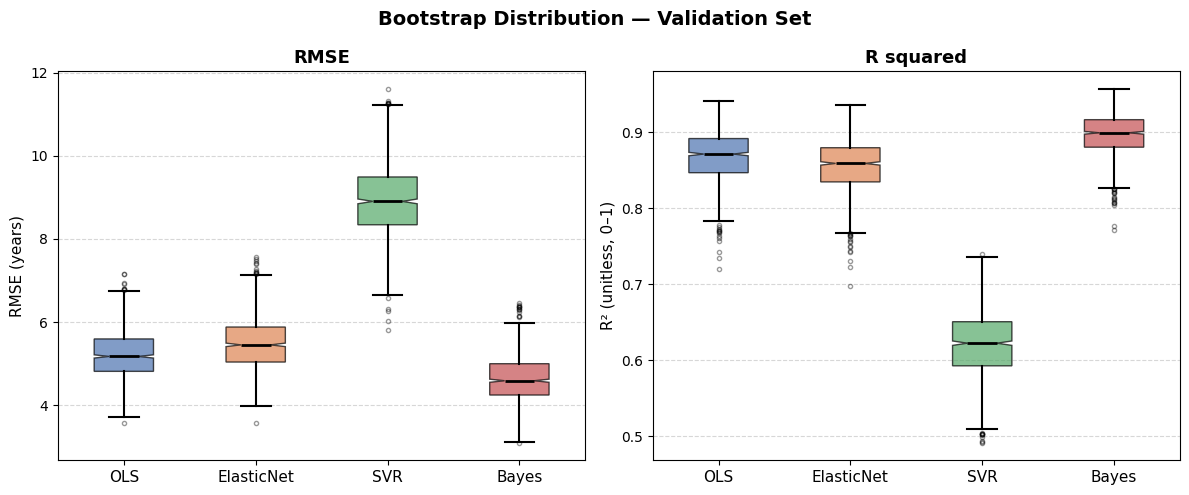

In [ ]:
plot_bootstrap_boxplots(
    dist_dict={
        "OLS":        ols_dist_val,
        "ElasticNet": enet_dist_val,
        "SVR":        svr_dist_val,
        "Bayes":      bayes_dist_val,
    }
)

## 4 Feature Selection

Feature selection is essential in  any Machine Learning pipeline for several reasons:
- Improves model accuracy, since model trains on the most informative features
- Faster training due to less features.
- More interpretable data
- More possible to provide predictions on new datasets with less features.
- Avoids the curse of dimensionality

Two different feature selection methods will be compared in this module (Stability selection and MRM)

In [10]:
#Initialize preprocessing transformer
preprocessor = preprocessing(X_train, impute_strategy_num='median', impute_strategy_cat='most_frequent')
preprocessor.set_output(transform="pandas")

#Fit and transform
X_train_processed = preprocessor.fit_transform(X_train) 
X_validate_processed = preprocessor.transform(X_validate)

### 4.1 Stability Selection

Feature Stability selection is a robust ML technique which identifies the most consistent and relevant features, by analyzing which ones are selected across multilple pertrubed versions of a dataset. It filters out features with weak relationships to the target variable, enhancing interpretability and generalizability.



First the preprocessing pipeline is used to fit and transform the training split, and transform the validation split, and produce usuable Pandas dataframe outputs, on which the stability selection algorithm will run

To implement Stability selection, 50 subsamples are drawn from the training split, and on each subsample, the top 200 features that are most correlated with age are kept. A feature is considered stable if it appears in more than half o the 50 subsamples. 

Number of stable features: 189


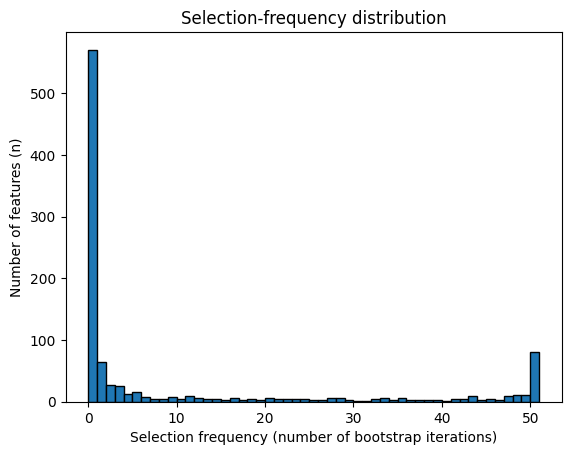

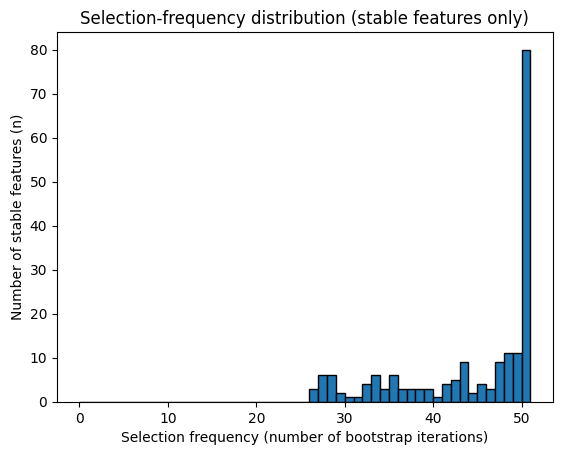

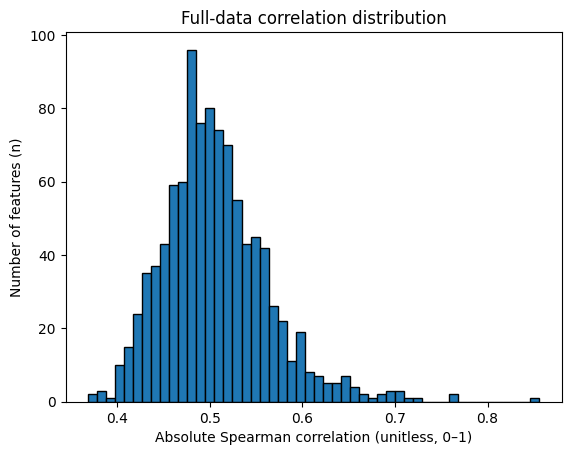

Top 10 correlations:      [0.85565111 0.76511589 0.76018418 0.72712307 0.71327871 0.70619974
 0.70410967 0.70052662 0.69644075 0.69634454]
Correlations at rank 11+: [0.69231646 0.69001294 0.68610858 0.6800191  0.66594725 0.66440099
 0.65734815 0.65719072 0.65539998 0.65285885]
Median correlation:       0.4996056780901471
y_train unique values: 67
y_train value counts:
 age
76     14
64     13
69     12
73     12
65     11
       ..
101     1
30      1
93      1
37      1
22      1
Name: count, Length: 67, dtype: int64
y_train dtype: int64
X_train shape: (364, 1000)
Any NaN in X_train: False
Any NaN in y_train: False
Number of stable features selected: 189
First 10 stable feature indices: [0 1 2 3 4 5 6 7 8 9]


(           Estimate        SD    CI_Low   CI_High
 Metric                                           
 RMSE       7.332084  0.916120  5.934769  9.728594
 MAE        5.363885  0.523107  4.539124  6.638370
 R_squared  0.748143  0.065186  0.567284  0.841223
 Pearson_r  0.867309  0.035502  0.764952  0.917904,
 {'RMSE': array([ 7.11962775,  7.48231342,  6.2917642 ,  8.62260808,  7.64144548,
          6.84461754,  6.2169969 ,  6.97152075,  8.30492976,  5.93044791,
          5.84322303,  6.34017985,  5.09177029,  8.17283427,  7.83908568,
          6.33695611,  8.85144398,  7.58303786,  7.02423966,  7.15420653,
          5.55635615,  6.489205  ,  7.26214605,  7.439506  ,  5.77182076,
          9.82210279,  7.75235719,  6.3742507 ,  7.23261664,  7.3167438 ,
          7.42190272,  8.19923175,  6.14251771,  7.39540723,  9.55155381,
          6.95530374,  7.1199235 ,  8.70759138,  6.54826064,  8.82286516,
          8.26542612,  6.1428832 ,  6.62495979,  7.13850974,  6.51773516,
          7.3375980

In [ ]:
stable_features, selection_counts = stability_selection(
    X_train=X_train_processed,
    y_train=y_train,
    resamples=50,
    top_k=200,
    subsample_fraction=0.8,
    seed=42
)

print("Number of stable features selected:", len(stable_features))
print("First 10 stable feature indices:", stable_features[:10])

stable_feature_names = X_train_processed.columns[stable_features]

ols_pipeline = Pipeline(steps=[
    ('model', LinearRegression())
])

# Fit on training set using only stable features
ols_pipeline.fit(X_train_processed.iloc[:, stable_features], y_train)

# Predict on validation set using the same columns
y_pred_stable = ols_pipeline.predict(X_validate_processed.iloc[:, stable_features])


stable_boot_results = bootstrap_evaluation(
    confidence=0.95,
    prediction=y_pred_stable,
    y_test=y_validate,
    resamples=1000,
    seed=42
)

display(stable_boot_results)

stable_feature_names = [
    col.replace("num__", "").replace("cat__", "")
    for col in stable_feature_names
]

The algorithm selected 189 features, representing a substantial reduction from the initial 1,000 CpG features in the dataset. Despite this reduction, the number of retained features is still relatively high. This is likely because stability selection prioritizes association with the target variable, but does not explicitly account for redundancy among features. In biological datasets, such redundancy can be considerable, as methylation at different CpG islands is often not independent due to coupled regulatory mechanisms, as in many other tightly regulated cellular processes.

Among the 189 selected features, many showed very high stability across subsamples. In particular, a pronounced peak is observed at features selected in all 50 subsamples, indicating a subset of highly robust predictors, alongside a broader distribution of less stable features with lower selection frequencies.

### 4.2 Minimum Redundancy Maximum Relevance (MRMR)

To address the inter-feature redundancy that is not considered by stability selection, mRMR feature selection can be applied. mRMR jointly optimizes two objectives: maximizing the association between features and the target variable (relevance), while minimizing redundancy among the selected features.

In addition, mRMR treats the maximum number of features to be selected (k) as a hyperparameter, and tuning this parameter is crucial for obtaining a feature set that is both informative and non-redundant.

#### 4.2.1 MRMR K tuning

To tune the k parameter in mRMR, a grid search–based approach is used. mRMR is applied across a broad range of k values, and the resulting feature sets are evaluated by 5-fold cross-validation on the training split using a simple OLS model as a proxy. The performance of the model associated with the best-performing k is then assessed on the validation split.

After this initial broad search, a narrower range of k values is defined around the most promising region. A second pass is then performed within this refined range to identify the optimal mRMR k more precisely.

100%|██████████| 400/400 [00:18<00:00, 21.31it/s]


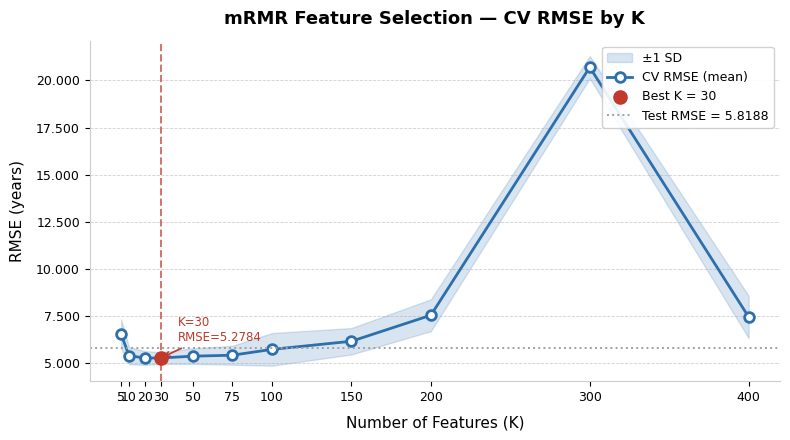

,K,cv_rmse,cv_rmse_sd
0,30,5.278434,0.308329
1,20,5.280212,0.367883
2,50,5.376480,0.411883
3,10,5.400783,0.451285
4,75,5.426697,0.502162
5,100,5.737379,0.865612
6,150,6.167891,0.700822
7,5,6.558583,0.764472
8,400,7.459542,1.121822
9,200,7.548849,0.844256


Best K: 30
Top 10 selected features: ['num__cg16867657', 'num__cg10501210', 'num__cg06639320', 'num__cg24724428', 'num__cg21572722', 'num__cg22454769', 'num__cg08234504', 'num__cg14692377', 'num__cg07082267', 'num__cg07955995']


In [ ]:
#Define k values grid
K_values = [5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400]

#Run the tuning function
results_df, best_K, best_features, test_rmse = mrmr_k_tuning(
    X_train=X_train_processed,
    y_train=y_train,
    X_test=X_validate_processed,
    y_test=y_validate,
    K_values=K_values
)

display(results_df[["K", "cv_rmse", "cv_rmse_sd"]])
print("Best K:", best_K)
print("Top 10 selected features:", best_features[:10])


In [ ]:
K_values = [10,20,30,40,60,80,100]

results_df, best_K, best_features, test_rmse = mrmr_k_tuning(
    X_train=X_train_processed,               
    y_train=y_train,
    X_test=X_validate_processed,              
    y_test=y_validate,
    K_values=K_values
)

display(results_df[["K", "cv_rmse", "cv_rmse_sd"]])
print("Best K:", best_K)
print("Top 10 selected features:", best_features[:10])

 47%|████▋     | 14/30 [00:01<00:01, 13.38it/s]


KeyboardInterrupt: 

After k hyperparameter tuning, MRMR with the selected optimal k:

In [11]:
k = 30

ols_pipeline = Pipeline(steps=[
    #('preprocessor', preprocessor),
    ('model', LinearRegression())
])

selected_topk = mrmr_selection(X_train_processed, y_train, K=k)

ols_pipeline.fit(X_train_processed[selected_topk], y_train)
y_pred_topk = ols_pipeline.predict(X_validate_processed[selected_topk])

mrmr_boot_results = bootstrap_evaluation(
    confidence=0.95,
    prediction=y_pred_topk,
    y_test=y_validate,
    resamples=1000,
    seed=42
)

display(mrmr_boot_results)

selected_topk = [
    col.replace("num__", "").replace("cat__", "")
    for col in selected_topk
]

100%|██████████| 30/30 [00:01<00:00, 18.85it/s]


['num__cg16867657', 'num__cg10501210', 'num__cg06639320', 'num__cg24724428', 'num__cg21572722', 'num__cg22454769', 'num__cg08234504', 'num__cg14692377', 'num__cg07082267', 'num__cg07955995', 'num__cg24079702', 'num__cg06784991', 'num__cg01974375', 'num__cg01763090', 'num__cg22796704', 'num__cg14361627', 'num__cg19283806', 'num__cg02650266', 'num__cg23744638', 'num__cg07553761', 'num__cg08097417', 'num__cg16932827', 'num__cg07547549', 'num__cg01528542', 'num__cg25994988', 'num__cg22736354', 'num__cg10149533', 'num__cg03607117', 'num__cg09809672', 'num__cg17110586']


(           Estimate        SD    CI_Low   CI_High
 Metric                                           
 RMSE       5.818830  0.657105  4.823597  7.702823
 MAE        4.277926  0.408902  3.568418  5.229175
 R_squared  0.841376  0.040072  0.744150  0.900884
 Pearson_r  0.918058  0.021676  0.862795  0.950607,
 {'RMSE': array([5.42769181, 5.74118059, 5.56119933, 6.91144702, 6.44890941,
         4.99258358, 6.00101432, 5.41108195, 5.9730727 , 6.3076412 ,
         5.48593523, 6.0210808 , 4.87293645, 5.21331305, 5.33410479,
         5.38538042, 6.57069878, 7.74342392, 4.90529001, 5.63902904,
         4.98058949, 5.61490039, 6.47263872, 6.79197746, 5.28598225,
         5.81257576, 5.1903782 , 5.69155853, 5.57236095, 5.39867656,
         5.85361101, 5.85219532, 6.03595413, 5.42094912, 6.98003404,
         5.4155877 , 5.21689981, 5.60562619, 5.74833709, 5.68591527,
         5.19483265, 5.07792762, 5.76940788, 5.92071641, 5.64965047,
         5.2038239 , 5.42426942, 5.21754129, 6.89291994, 5.45250

### 4.3 Method comparison:

Generate Comparative Venn diagram:

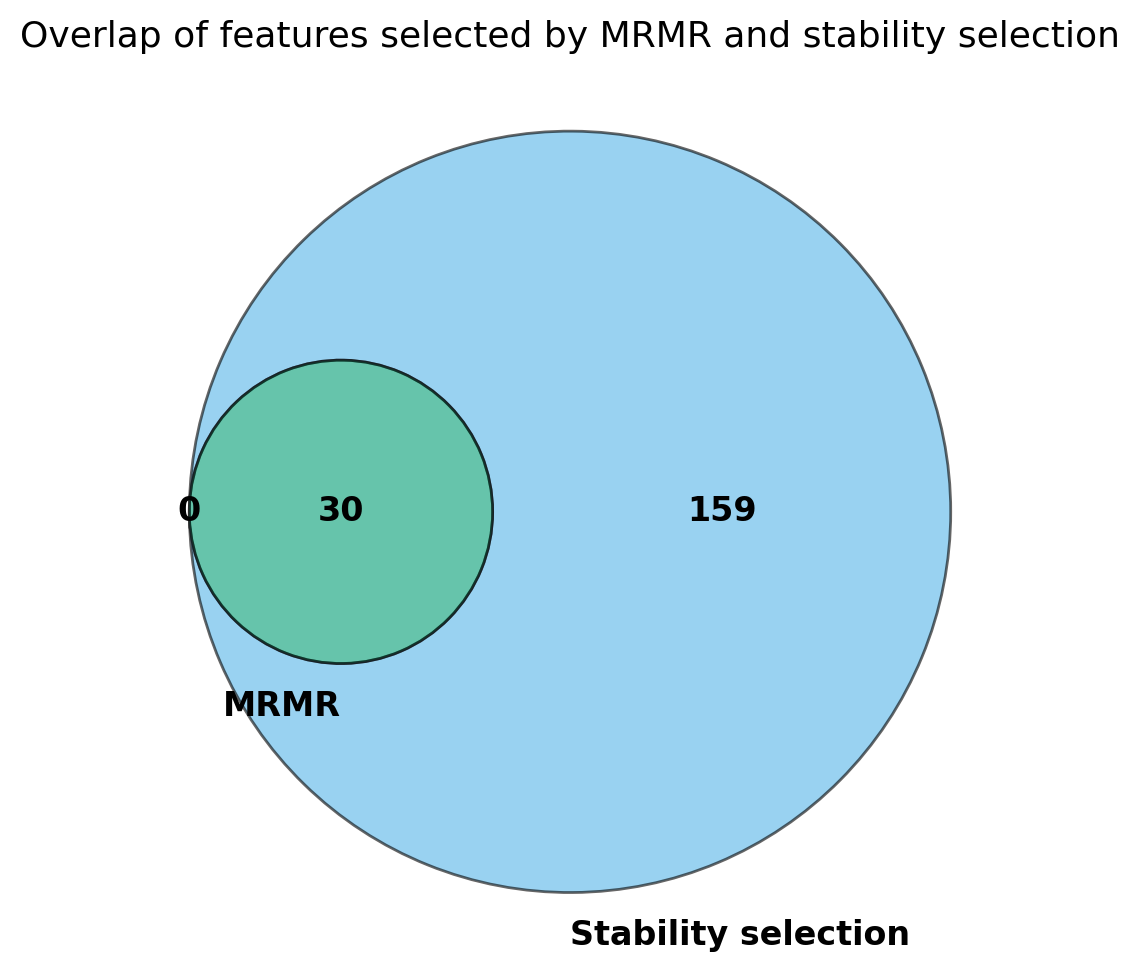

In [ ]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

mrmr_set = set(selected_topk)
stable_set = set(stable_feature_names)

plt.figure(figsize=(6, 5), dpi=200)
v = venn2(
    [mrmr_set, stable_set],
    set_labels=("MRMR", "Stability selection")
)

# Softer, cleaner fills
v.get_patch_by_id('10').set_color('#E69F00')   # MRMR only
v.get_patch_by_id('01').set_color('#56B4E9')   # Stability only
v.get_patch_by_id('11').set_color('#009E73')   # Overlap

for pid in ['10', '01', '11']:
    patch = v.get_patch_by_id(pid)
    if patch is not None:
        patch.set_alpha(0.6)
        patch.set_edgecolor("black")
        patch.set_linewidth(1.0)

# Style the numbers inside circles
for pid in ['10', '01', '11']:
    label = v.get_label_by_id(pid)
    if label is not None:
        label.set_fontsize(12)
        label.set_fontweight("bold")

# Style set labels
for label in v.set_labels:
    if label is not None:
        label.set_fontsize(12)
        label.set_fontweight("bold")

plt.title("Overlap of features selected by MRMR and stability selection", fontsize=13)
plt.tight_layout()
plt.show()

When comparing the results of the two feature selection methods, MRMR shows clearly superior performance. Despite selecting fewer than half as many features as stability selection (90 vs. 189), the OLS proxy model performs substantially better on the MRMR-derived feature matrix, with lower RMSE and higher Pearson’s r than on the feature matrix obtained through stability selection. These results indicate that MRMR yields a more compact and informative feature set, leading to more accurate and interpretable model predictions.

Based on these findings, MRMR was selected as the preferred feature selection strategy for this pipeline.

### 4.4 Baseline Models performance evaluation with MRMR selected features.

The performance of each one of the baseline models was assesed using the MRMR selected features using the validation split.

In [ ]:
#Construct new X and y vectors with the selected features only.
X_train_topk = X_train[selected_topk]
X_validate_topk = X_validate[selected_topk]

models_mrmr = {
    "OLS": LinearRegression(),
    "Elastic_net": ElasticNet(random_state=42, alpha=1.0, l1_ratio=0.5),
    "SVR": SVR(kernel="rbf"),
    "Bayesian_Ridge": BayesianRidge()
}

summary_df_mrmr = run_models(models_mrmr, X_train_topk, y_train, X_validate_topk, y_validate)
display(summary_df_mrmr)

,Estimate,SD,CI_Low,CI_High,metric,model,dataset
0,4.643278,0.207084,4.276539,5.068117,RMSE,OLS,train
1,3.574676,0.153600,3.308082,3.901129,MAE,OLS,train
2,0.899088,0.011571,0.873849,0.918985,R_squared,OLS,train
3,0.948202,0.006096,0.934649,0.958446,Pearson_r,OLS,train
4,5.818830,0.657105,4.823597,7.702823,RMSE,OLS,validate
5,4.277926,0.408902,3.568418,5.229175,MAE,OLS,validate
6,0.841376,0.040072,0.744150,0.900884,R_squared,OLS,validate
7,0.918058,0.021676,0.862795,0.950607,Pearson_r,OLS,validate
8,4.963783,0.203189,4.592766,5.381934,RMSE,Elastic_net,train
9,3.910650,0.158259,3.646556,4.267102,MAE,Elastic_net,train


After feature selection, the performance of all baseline models declined relative to the full feature matrix. This does not necessarily indicate that mRMR failed to identify the most informative features. Rather, it suggests that some predictive signal was lost during feature reduction, likely because the initial set of 1,000 features already comprised those most strongly correlated with the target variable. Nevertheless, this modest decrease in predictive performance is largely compensated by the substantial gain in simplicity and interpretability achieved with a much smaller feature set, reducing the number of features from 1,000 to 90.

Among the four evaluated regression models, Bayesian Ridge showed the best predictive performance on the validation dataset, achieving the lowest RMSE and MAE, as well as the highest R² and Pearson’s r. OLS and Elastic Net also performed well, with only slightly lower validation performance, indicating that age can be predicted effectively from the selected methylation features using linear methods. In contrast, SVR showed clearly inferior generalization performance, with substantially higher prediction error and lower explanatory power. Overall, these results identify Bayesian Ridge as the most suitable model at this stage of the pipeline.

## 5. Hyperparameter Tuning:

It is relatively uncommon for a model to perform optimally when trained using its default hyperparameters. Hyperparameters, unlike model parameters learned from the data, are set before training and can substantially influence training time, computational cost, and predictive accuracy. Proper hyperparameter tuning is therefore essential for achieving strong model performance.

In this module, two different methods for hyperparamter tuning will be compared:
- Randomized Search with Cross Validation
- Optuna Hyperparameter tuning.

Both will be used to tweak the hyperparameters of all three baseline models, and the best set of hyperparameters will be used for final model evaluation.

### 5.1 Randomized Search

Randomized Search is a hyperparameter tuning technique that explores a predefined distribution of model parameters. Compared with Grid Search, it is generally more efficient because it randomly samples a fixed number of parameter combinations from the specified distributions, rather than exhaustively evaluating every possible combination. For this reason, Randomized Search is particularly well suited to large hyperparameter spaces or settings with limited computational resources. However, because the search is based on random sampling, it may miss the optimal parameter combination, and the quality of the final result depends strongly on the number of trials performed.

In [ ]:
# Define feature exploration space for each model
models_to_tune = {
    "ElasticNet": {
        "model": ElasticNet(),
        "param_distributions": {
            "alpha": loguniform(0.001, 10),
            "l1_ratio": uniform(0.1, 0.9)
        }
    },
    "SVR": {
        "model": SVR(),
        "param_distributions": {
            "C": loguniform(0.1, 500),
            "epsilon": [0.01, 0.1, 0.5, 1.0],
            "kernel": ["rbf", "linear"]
        }
    },
    "BayesianRidge": {
        "model": BayesianRidge(),
        "param_distributions": {
            "alpha_1": loguniform(1e-7, 1e-3),
            "alpha_2": loguniform(1e-7, 1e-3),
            "lambda_1": loguniform(1e-7, 1e-3),
            "lambda_2": loguniform(1e-7, 1e-3)
        }
    }
}

all_results = tune_multiple_models(
    X=X_development,
    y=y_development,
    models_to_tune=models_to_tune
)

display(all_results["summary_df"])

print("Best model type:", all_results["best_model_name"])
print("Best params:", all_results["final_params"])

best_model = all_results["final_model"]
best_preprocessor = all_results["final_preprocessor"]
best_features = all_results["final_selected_features"]


Tuning ElasticNet...
Best CV RMSE: 5.4442
Best params: {'alpha': np.float64(0.2801635158716261), 'l1_ratio': np.float64(0.22554447458683766)}

Tuning SVR...
Best CV RMSE: 5.5088
Best params: {'C': np.float64(0.9061902594114375), 'epsilon': 1.0, 'kernel': 'linear'}

Tuning BayesianRidge...
Best CV RMSE: 5.4972
Best params: {'alpha_1': np.float64(3.798214508453255e-07), 'alpha_2': np.float64(9.074256288983855e-06), 'lambda_1': np.float64(0.0008761971101023686), 'lambda_2': np.float64(9.294394155644988e-07)}

Best model type: ElasticNet


,Model,Best CV RMSE
0,ElasticNet,5.444205
1,BayesianRidge,5.497234
2,SVR,5.508838


Best model type: ElasticNet
Best params: {'alpha': np.float64(0.2801635158716261), 'l1_ratio': np.float64(0.22554447458683766)}


### 5.2 Optuna Hyperparameter search

Despite the high speed and efficiency exhibited by Random Search, and the improvement of model performance compared to the untuned models, randomized search does not use any specific algorithm, and does nnot take pervious iterations into considerations, but only randomly tests hyperparameters that fall within the given range.

Hyperparameter tuning can be greatly improved by 

Optuna is based on *studies* and *trials*:
- A study is the process of the optimization based on a set objective function.
- A trial is a single execution of the objective function.

-> The goal of a study is to find the otpimal set of the hyperparameter values through mmultiple trials. Optuna automates the hyperparameter tuning process using Bayesian optimization via the Tree-structured Parzen Estimator (TPE). (More info on TPE is provided in the Report file)

[I 2026-03-30 19:27:53,486] A new study created in memory with name: no-name-0a4f0dd4-0679-45f0-8ca4-5b41eca407ee



Tuning ElasticNet...


[I 2026-03-30 19:28:03,058] Trial 0 finished with value: 5.507921073759271 and parameters: {'alpha': 0.03148911647956861, 'l1_ratio': 0.9556428757689246}. Best is trial 0 with value: 5.507921073759271.
[I 2026-03-30 19:28:12,647] Trial 1 finished with value: 5.500188818014674 and parameters: {'alpha': 0.8471801418819978, 'l1_ratio': 0.6387926357773329}. Best is trial 1 with value: 5.500188818014674.
[I 2026-03-30 19:28:21,759] Trial 2 finished with value: 5.555748007527351 and parameters: {'alpha': 0.004207988669606638, 'l1_ratio': 0.2403950683025824}. Best is trial 1 with value: 5.500188818014674.
[I 2026-03-30 19:28:31,403] Trial 3 finished with value: 5.559605913710455 and parameters: {'alpha': 0.0017073967431528124, 'l1_ratio': 0.8795585311974417}. Best is trial 1 with value: 5.500188818014674.
[I 2026-03-30 19:28:41,469] Trial 4 finished with value: 5.455200420170329 and parameters: {'alpha': 0.2537815508265665, 'l1_ratio': 0.737265320016441}. Best is trial 4 with value: 5.4552004

Hyperparameter,Value
alpha,0.389259
l1_ratio,0.616004
CV RMSE (best trial),5.447700


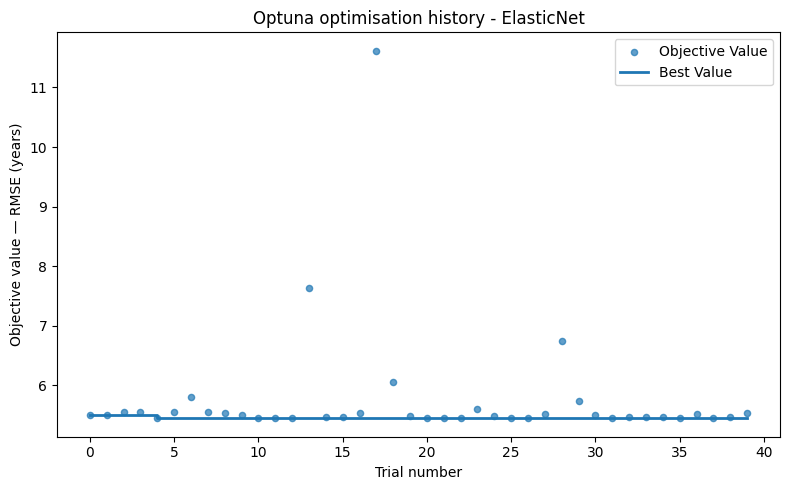

[I 2026-03-30 19:34:11,350] A new study created in memory with name: no-name-2740cec7-42c3-48b6-ade3-c65581ae895c


Best CV RMSE: 5.4477
Best params: {'alpha': 0.38925865318425046, 'l1_ratio': 0.6160040542472924}

Tuning SVR...


[I 2026-03-30 19:34:20,691] Trial 0 finished with value: 7.143442656648263 and parameters: {'C': 2.4289169469748875, 'epsilon': 0.01, 'kernel': 'rbf'}. Best is trial 0 with value: 7.143442656648263.
[I 2026-03-30 19:34:30,564] Trial 1 finished with value: 6.478974949505314 and parameters: {'C': 159.94091701280448, 'epsilon': 1.0, 'kernel': 'rbf'}. Best is trial 1 with value: 6.478974949505314.
[I 2026-03-30 19:34:40,595] Trial 2 finished with value: 5.5691388825408294 and parameters: {'C': 0.4705059281907647, 'epsilon': 0.5, 'kernel': 'linear'}. Best is trial 2 with value: 5.5691388825408294.
[I 2026-03-30 19:34:50,773] Trial 3 finished with value: 5.469631224095631 and parameters: {'C': 0.32808290847300486, 'epsilon': 1.0, 'kernel': 'linear'}. Best is trial 3 with value: 5.469631224095631.
[I 2026-03-30 19:35:02,382] Trial 4 finished with value: 5.615943938663538 and parameters: {'C': 15.535445807588452, 'epsilon': 0.1, 'kernel': 'linear'}. Best is trial 3 with value: 5.46963122409563

Hyperparameter,Value
C,0.328083
epsilon,1.000000
kernel,linear
CV RMSE (best trial),5.469600


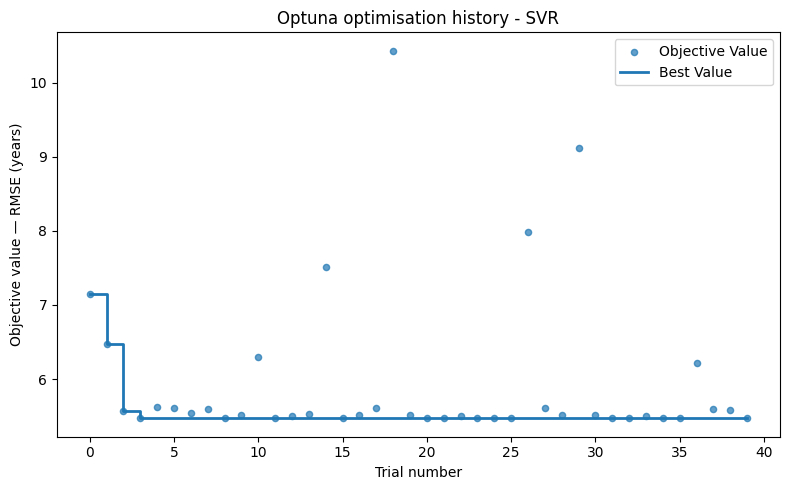

[I 2026-03-30 19:41:08,067] A new study created in memory with name: no-name-b2a54e99-3f20-4aa2-9cdb-29023458a953


Best CV RMSE: 5.4696
Best params: {'C': 0.32808290847300486, 'epsilon': 1.0, 'kernel': 'linear'}

Tuning BayesianRidge...


[I 2026-03-30 19:41:17,737] Trial 0 finished with value: 5.49723642061187 and parameters: {'alpha_1': 3.14891164795686e-06, 'alpha_2': 0.0006351221010640698, 'lambda_1': 8.471801418819978e-05, 'lambda_2': 2.481040974867808e-05}. Best is trial 0 with value: 5.49723642061187.
[I 2026-03-30 19:41:27,595] Trial 1 finished with value: 5.497237541596161 and parameters: {'alpha_1': 4.20798866960663e-07, 'alpha_2': 4.207053950287931e-07, 'lambda_1': 1.7073967431528095e-07, 'lambda_2': 0.0002915443189153752}. Best is trial 0 with value: 5.49723642061187.
[I 2026-03-30 19:41:36,903] Trial 2 finished with value: 5.4972390570696055 and parameters: {'alpha_1': 2.5378155082656606e-05, 'alpha_2': 6.796578090758147e-05, 'lambda_1': 1.208754147305695e-07, 'lambda_2': 0.0007579479953348002}. Best is trial 0 with value: 5.49723642061187.
[I 2026-03-30 19:41:46,114] Trial 3 finished with value: 5.497236643777909 and parameters: {'alpha_1': 0.00021368329072358748, 'alpha_2': 7.068974950624599e-07, 'lambda_

Hyperparameter,Value
alpha_1,0.000003
alpha_2,0.000180
lambda_1,0.000994
lambda_2,0.000052
CV RMSE (best trial),5.497200


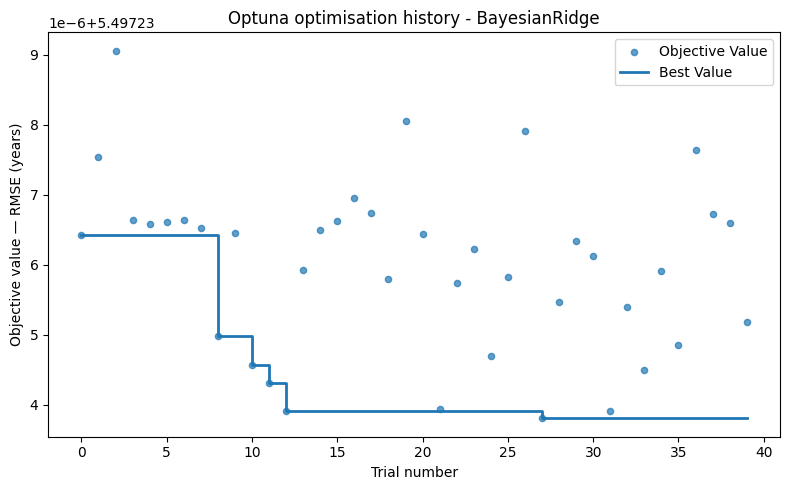

Best CV RMSE: 5.4972
Best params: {'alpha_1': 2.682794643353879e-06, 'alpha_2': 0.0001802913216152517, 'lambda_1': 0.0009944481682415277, 'lambda_2': 5.1639947930308126e-05}

Best model type: ElasticNet


,Model,Best CV RMSE
0,ElasticNet,5.447748
1,SVR,5.469631
2,BayesianRidge,5.497234


Best model type: ElasticNet
Best params: {'alpha': 0.38925865318425046, 'l1_ratio': 0.6160040542472924}


In [ ]:

models = {
    "ElasticNet": ElasticNet(),
    "SVR": SVR(),
    "BayesianRidge": BayesianRidge()
}

optuna_results = optuna_tune_multiple_models(
    models=models,
    X_train=X_development,
    y_train=y_development,
    k=30,
    n_trials=40,
    cv=5,
    seed=42,
    plot_history=True
)

display(optuna_results["summary_df"])

print("Best model type:", optuna_results["best_model_name"])
print("Best params:", optuna_results["final_params"])

best_model = optuna_results["final_model"]
best_preprocessor = optuna_results["final_preprocessor"]
best_features = optuna_results["final_selected_features"]
best_study = optuna_results["final_study"]

## Final model Evaluation

In [15]:
X_evaluation = build_feature_matrices(evaluation_df)["2. Methylation Only"]
X_evaluation_topk = evaluation_df[selected_topk]
y_evaluation = evaluation_df["age"]
X_development_topk = X_development[selected_topk]

In [ ]:
evaluation_models_baseline = {
    "OLS": LinearRegression(),
    "Elastic_net": ElasticNet(random_state=42, alpha=1.0, l1_ratio=0.5),
    "SVR": SVR(kernel="rbf"),
    "Bayesian_Ridge": BayesianRidge()
}

summary_df_baseline = run_models(evaluation_models_baseline, X_development, y_development, X_evaluation, y_evaluation)
display(summary_df_baseline)


evaluation_models_mrmr = {
    "OLS": LinearRegression(),
    "Elastic_net": ElasticNet(random_state=42, alpha=1.0, l1_ratio=0.5),
    "SVR": SVR(kernel="rbf"),
    "Bayesian_Ridge": BayesianRidge()
}

summary_df_mrmr = run_models(evaluation_models_mrmr, X_development_topk, y_development, X_evaluation_topk, y_evaluation)
display(summary_df_mrmr)

evaluation_models_tuned = {
    "OLS": LinearRegression(),
    "Elastic_net": ElasticNet(random_state=42, alpha=0.389259, l1_ratio=0.616004),
    "SVR": SVR(C = 0.328083,epsilon = 1.00, kernel="linear"),
    "Bayesian_Ridge": BayesianRidge(alpha_1=0.000003, alpha_2=0.000180,lambda_1=0.000994,lambda_2=0.000052)
}

summary_df_tuned = run_models(evaluation_models_tuned, X_development_topk, y_development, X_evaluation_topk, y_evaluation)
display(summary_df_tuned)

,Estimate,SD,CI_Low,CI_High,metric,model,dataset
0,5.024847e-14,2.329813e-15,4.645280e-14,5.571947e-14,RMSE,OLS,train
1,3.775537e-14,1.518963e-15,3.484620e-14,4.094970e-14,MAE,OLS,train
2,1.000000e+00,0.000000e+00,NaN,NaN,R_squared,OLS,train
3,1.000000e+00,1.131141e-16,1.000000e+00,1.000000e+00,Pearson_r,OLS,train
4,6.292780e+00,7.906533e-01,5.116733e+00,8.611714e+00,RMSE,OLS,validate
5,4.625125e+00,4.315016e-01,3.871865e+00,5.562034e+00,MAE,OLS,validate
6,8.057440e-01,6.040530e-02,6.261240e-01,8.852899e-01,R_squared,OLS,validate
7,9.084172e-01,2.577814e-02,8.275328e-01,9.421970e-01,Pearson_r,OLS,validate
8,4.077347e+00,1.673737e-01,3.811166e+00,4.501389e+00,RMSE,Elastic_net,train
9,3.184246e+00,1.165750e-01,2.981462e+00,3.434301e+00,MAE,Elastic_net,train


,Estimate,SD,CI_Low,CI_High,metric,model,dataset
0,4.850343,0.223206,4.497003,5.398126,RMSE,OLS,train
1,3.696687,0.148644,3.439442,4.030684,MAE,OLS,train
2,0.889873,0.012705,0.862233,0.911998,R_squared,OLS,train
3,0.943331,0.006723,0.928435,0.955123,Pearson_r,OLS,train
4,5.539619,0.483609,4.739441,6.688008,RMSE,OLS,validate
5,4.235862,0.356886,3.633162,5.039290,MAE,OLS,validate
6,0.849461,0.036502,0.759941,0.904949,R_squared,OLS,validate
7,0.922807,0.018934,0.874224,0.950957,Pearson_r,OLS,validate
8,5.136884,0.225066,4.777228,5.670589,RMSE,Elastic_net,train
9,3.976514,0.152707,3.705790,4.285786,MAE,Elastic_net,train


,Estimate,SD,CI_Low,CI_High,metric,model,dataset
0,4.850343,0.223206,4.497003,5.398126,RMSE,OLS,train
1,3.696687,0.148644,3.439442,4.030684,MAE,OLS,train
2,0.889873,0.012705,0.862233,0.911998,R_squared,OLS,train
3,0.943331,0.006723,0.928435,0.955123,Pearson_r,OLS,train
4,5.539619,0.483609,4.739441,6.688008,RMSE,OLS,validate
5,4.235862,0.356886,3.633162,5.039290,MAE,OLS,validate
6,0.849461,0.036502,0.759941,0.904949,R_squared,OLS,validate
7,0.922807,0.018934,0.874224,0.950957,Pearson_r,OLS,validate
8,4.940704,0.228788,4.576815,5.510391,RMSE,Elastic_net,train
9,3.746216,0.152558,3.474376,4.069422,MAE,Elastic_net,train


Comparison Box Plots

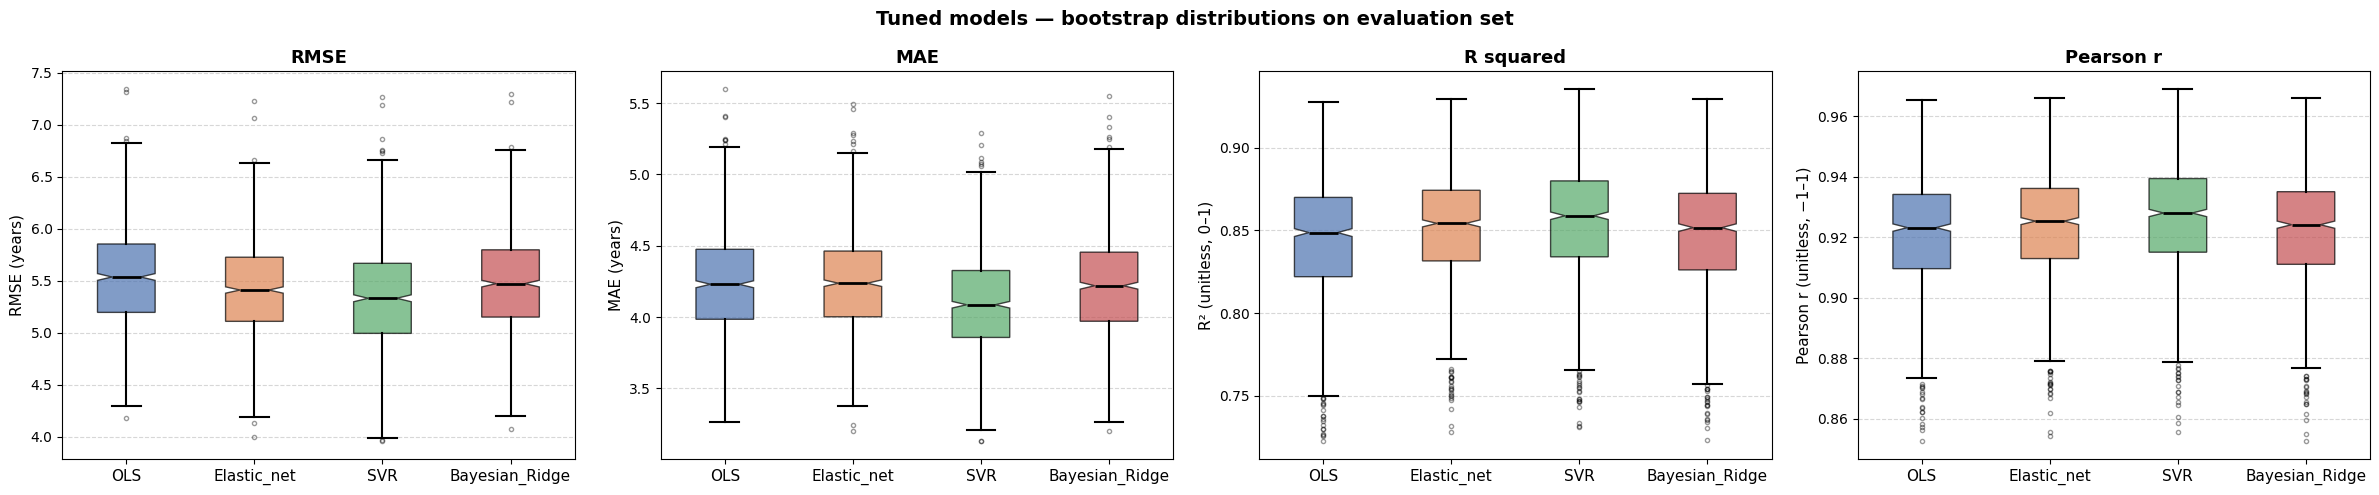

In [ ]:
tuned_dist_dict = collect_bootstrap_distributions(
    evaluation_models_tuned,
    X_development_topk,
    y_development,
    X_evaluation_topk,
    y_evaluation
)

plot_bootstrap_boxplots(
    tuned_dist_dict,
    metric_list=["RMSE", "MAE", "R_squared", "Pearson_r"],
    title="Tuned models — bootstrap distributions on evaluation set"
)

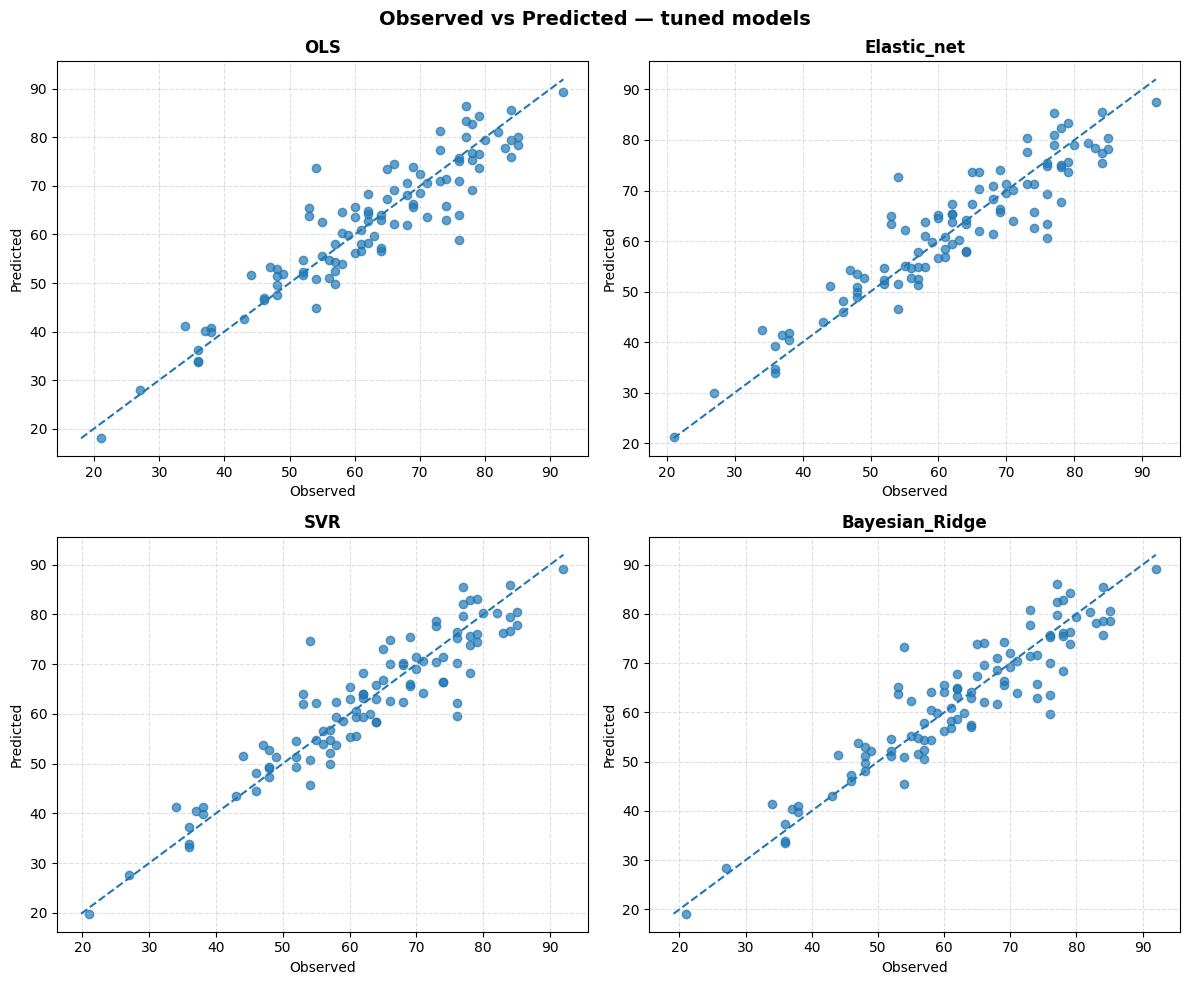

In [ ]:
plot_observed_vs_predicted(
    models=evaluation_models_tuned,
    X_train=X_development_topk,
    y_train=y_development,
    X_validate=X_evaluation_topk,
    y_validate=y_evaluation,
    title="Observed vs Predicted — tuned models"
)

Save the Best Elastic Net model

In [22]:
# Use full unfiltered data this time
X_all = pd.concat([X_development_topk, X_evaluation_topk])
y_all = pd.concat([y_development, y_evaluation])

preprocessor_final = preprocessing(X_all, impute_strategy_num='median', impute_strategy_cat='most_frequent')

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_final),
    ("model", ElasticNet(random_state=42, alpha=0.389259, l1_ratio=0.616004))
])

final_pipeline.fit(X_all, y_all)

joblib.dump(final_pipeline, "../models/final_pipeline.pkl")
joblib.dump(selected_topk, "../models/selected_topk.pkl")


['../models/selected_topk.pkl']

In [20]:
X_all.head

<bound method NDFrame.head of     cg16867657  cg10501210  cg06639320  cg24724428  cg21572722  cg22454769  \
0     0.672001    0.642512    0.504461    0.331257    0.444902    0.572867   
1     0.555411    0.610350    0.389214    0.160708    0.381837    0.464971   
2     0.781318    0.394829    0.554360    0.337578    0.505999    0.645529   
3     0.542491    0.807478    0.435584    0.228723    0.424905    0.493908   
4     0.653190    0.490451    0.466217    0.208453    0.434244    0.592122   
..         ...         ...         ...         ...         ...         ...   
95    0.661310    0.357736    0.483250    0.280883    0.440172    0.676650   
96    0.622762    0.469208    0.455474    0.220112    0.442863    0.662019   
97    0.626447    0.602601    0.392548    0.286777    0.461146    0.515062   
98    0.765177    0.299797    0.488672    0.342981    0.474376    0.588491   
99    0.462999    0.948975    0.357787    0.116876    0.358152    0.386690   

    cg08234504  cg14692377  cg070

## Sex Prediction

100%|██████████| 30/30 [00:01<00:00, 18.93it/s]


['num__cg16686396', 'num__cg00745389', 'num__cg11807280', 'num__cg12899747', 'num__cg05207637', 'num__cg01101873', 'num__cg00387658', 'num__cg19433091', 'num__cg05304393', 'num__cg20359994', 'num__cg07529654', 'num__cg06060874', 'num__cg07715777', 'num__cg15802091', 'num__cg24667575', 'num__cg19908207', 'num__cg15704699', 'num__cg16983588', 'num__cg24350475', 'num__cg02188818', 'num__cg22273555', 'num__cg00740914', 'num__cg00327072', 'num__cg26290219', 'num__cg01511567', 'num__cg22986597', 'num__cg03126058', 'num__cg05324516', 'num__cg18990365', 'num__cg04400972']
 Running Logistic Regression

Model performance — Logistic Regression — Evaluation set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
Accuracy,0.900000,0.030142,0.840000,0.950000
F1,0.880952,0.039273,0.800000,0.948718
MCC,0.794745,0.062593,0.669976,0.904032
ROC_AUC,0.947044,0.023752,0.895818,0.987502
PR_AUC,0.944575,0.026339,0.883051,0.987027


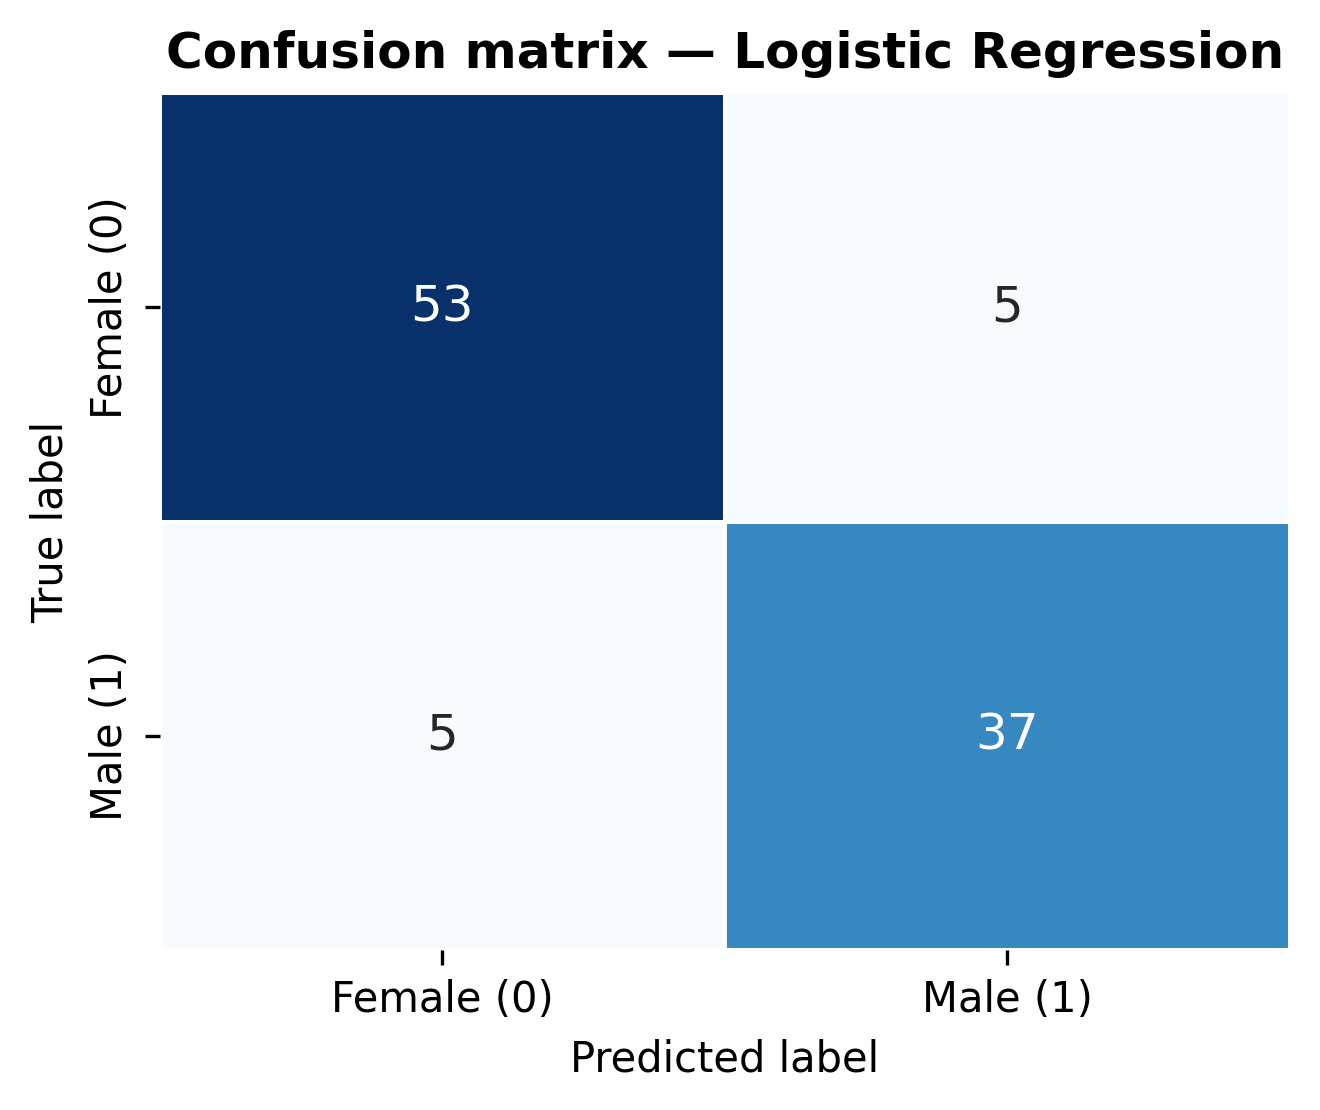

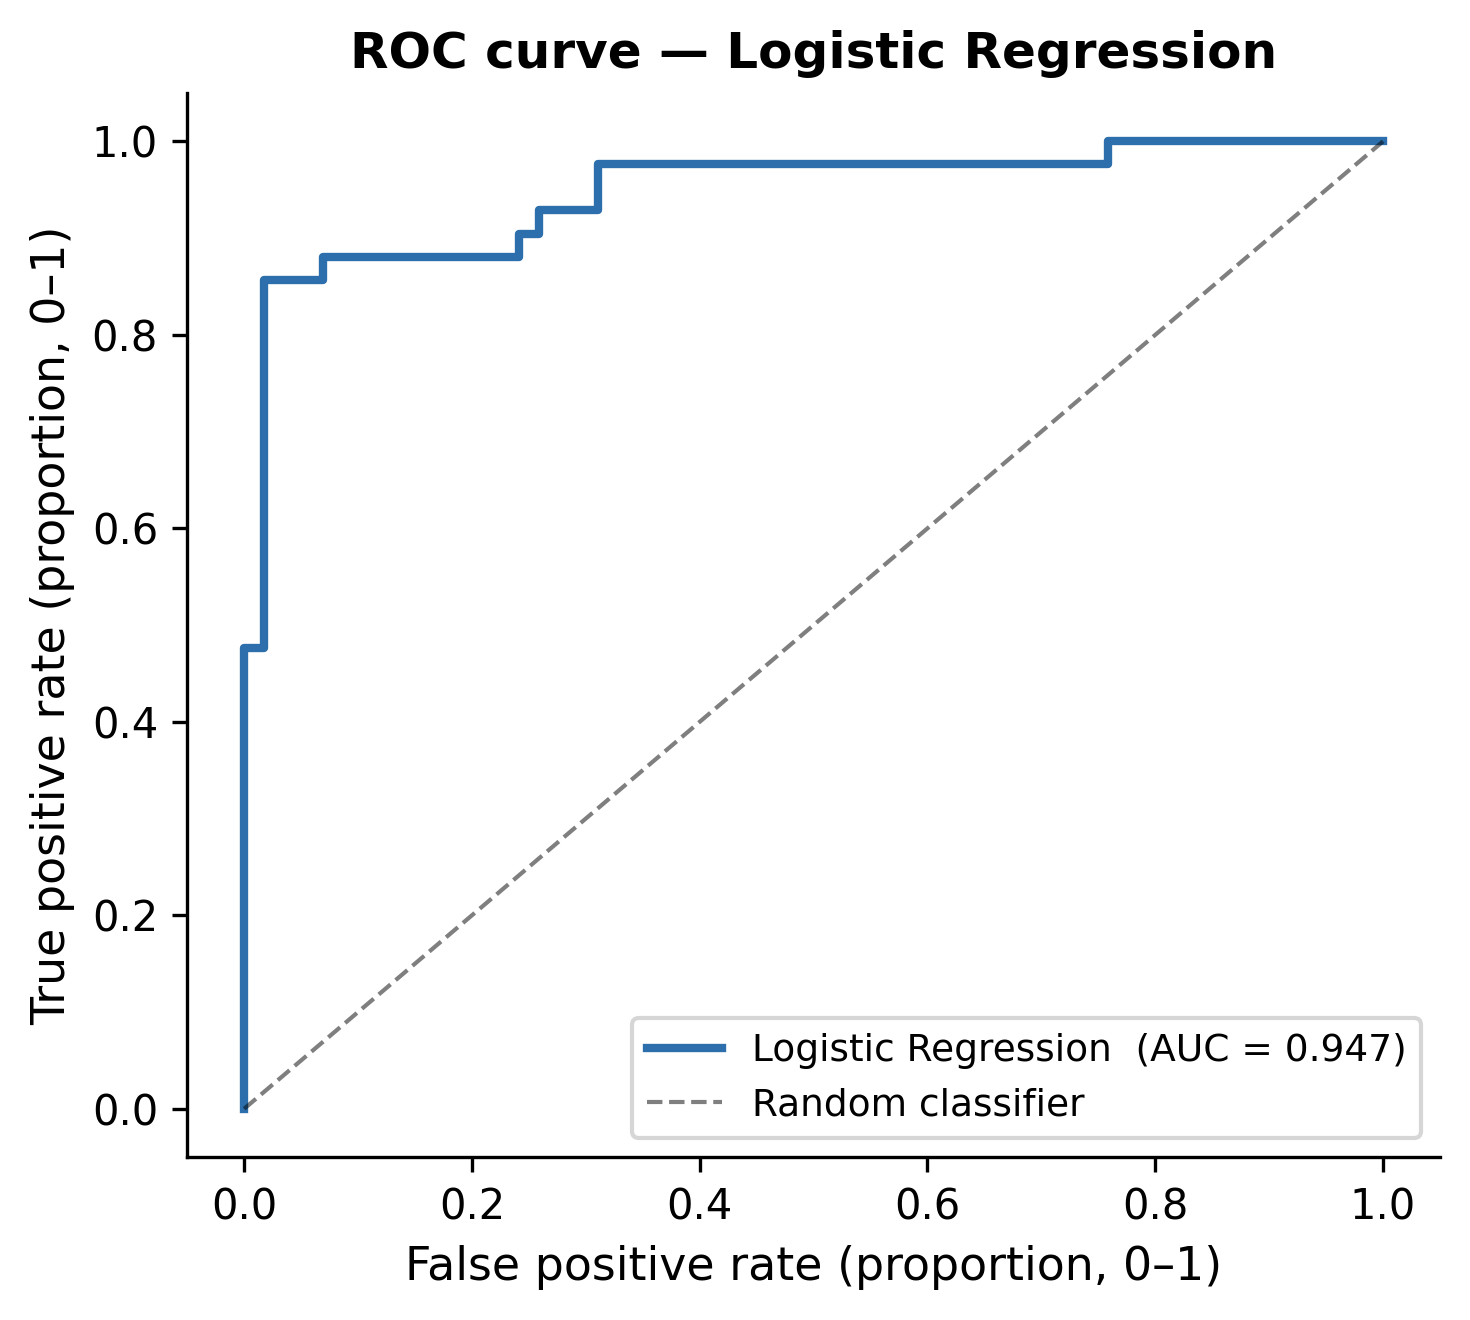

 Running Gaussian NB

Model performance — Gaussian NB — Evaluation set


,Estimate,SD,CI_Low,CI_High
Metric,,,,
Accuracy,0.730000,0.045424,0.630000,0.810000
F1,0.682353,0.059618,0.555482,0.785734
MCC,0.447721,0.092612,0.255020,0.616659
ROC_AUC,0.792693,0.044648,0.694417,0.874308
PR_AUC,0.707827,0.068842,0.571580,0.841961


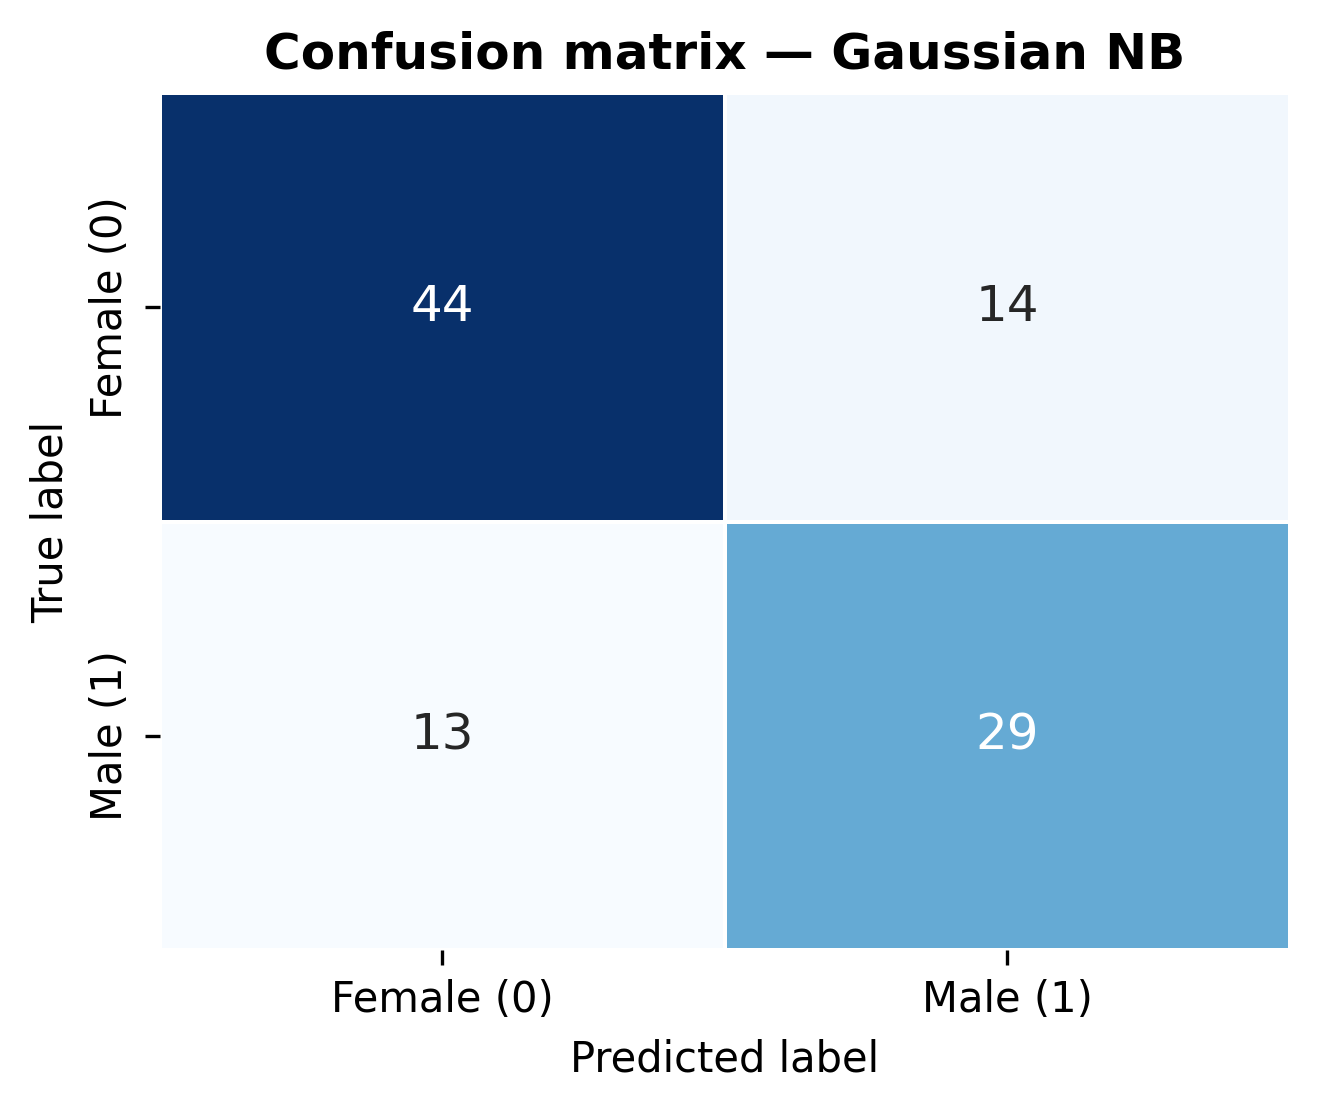

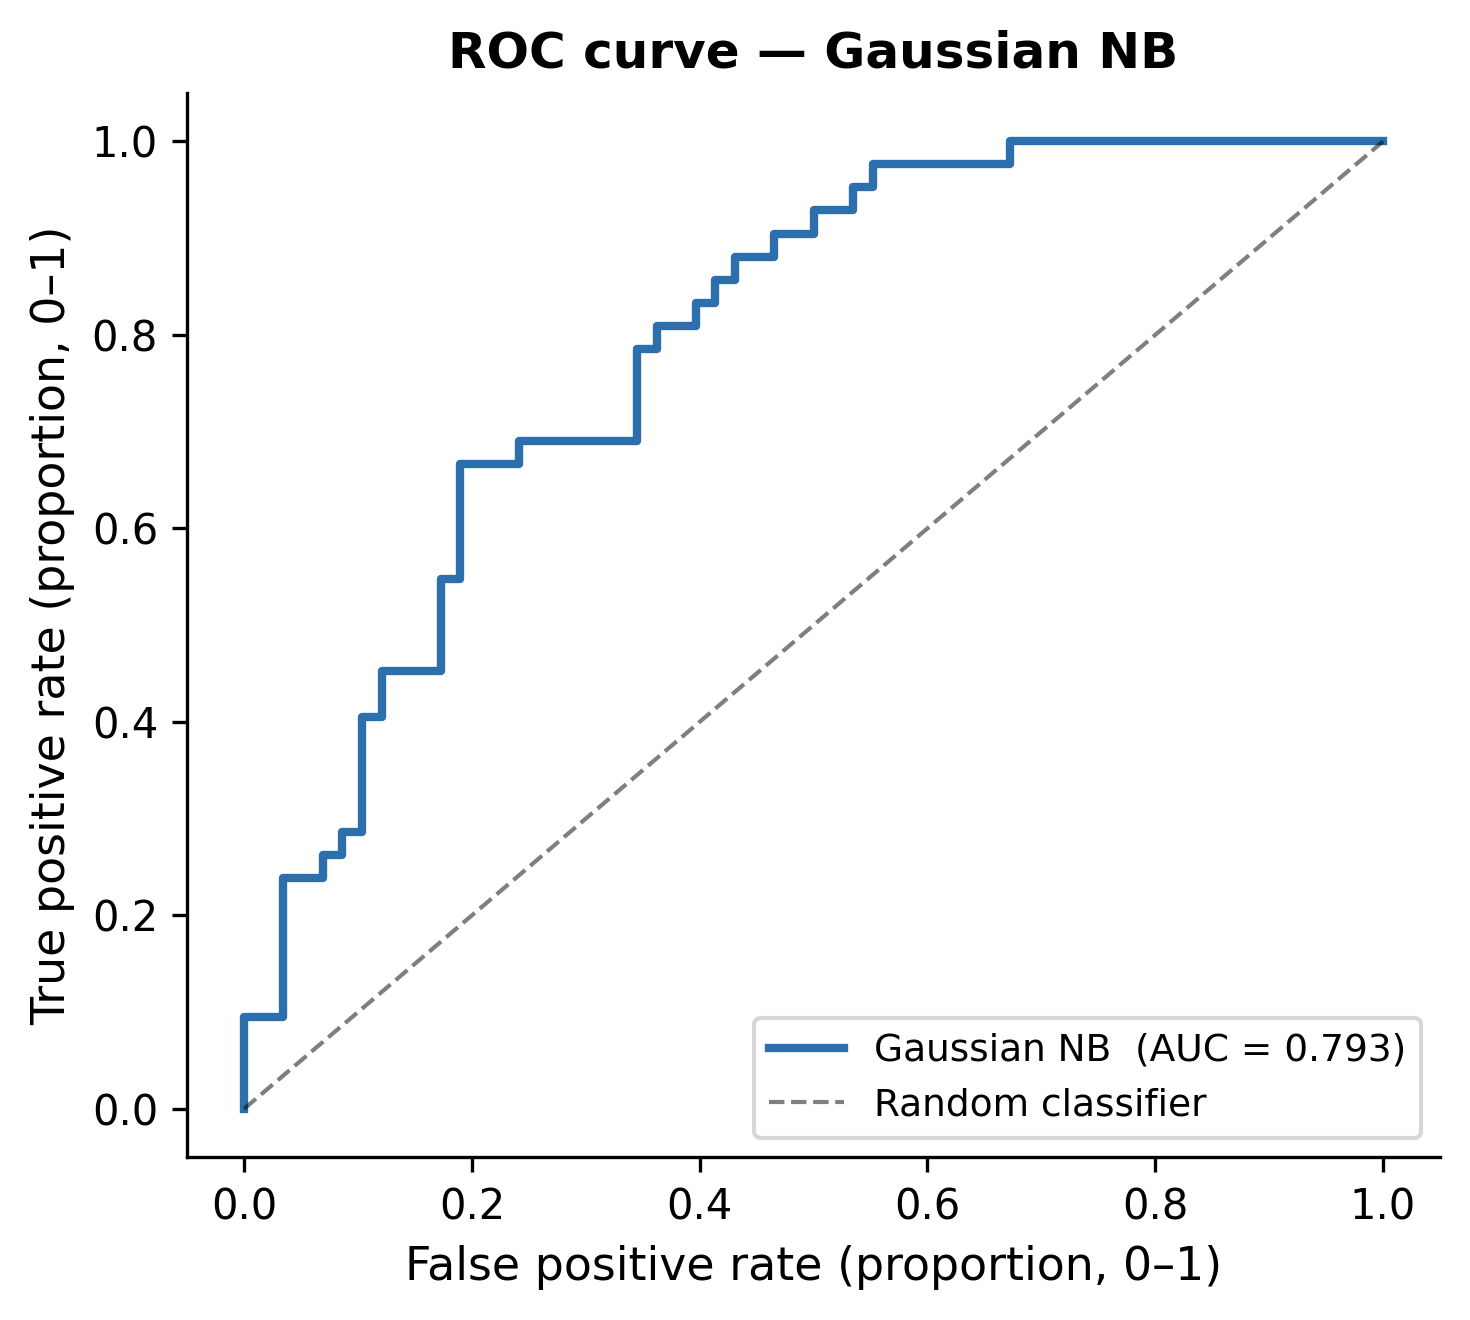

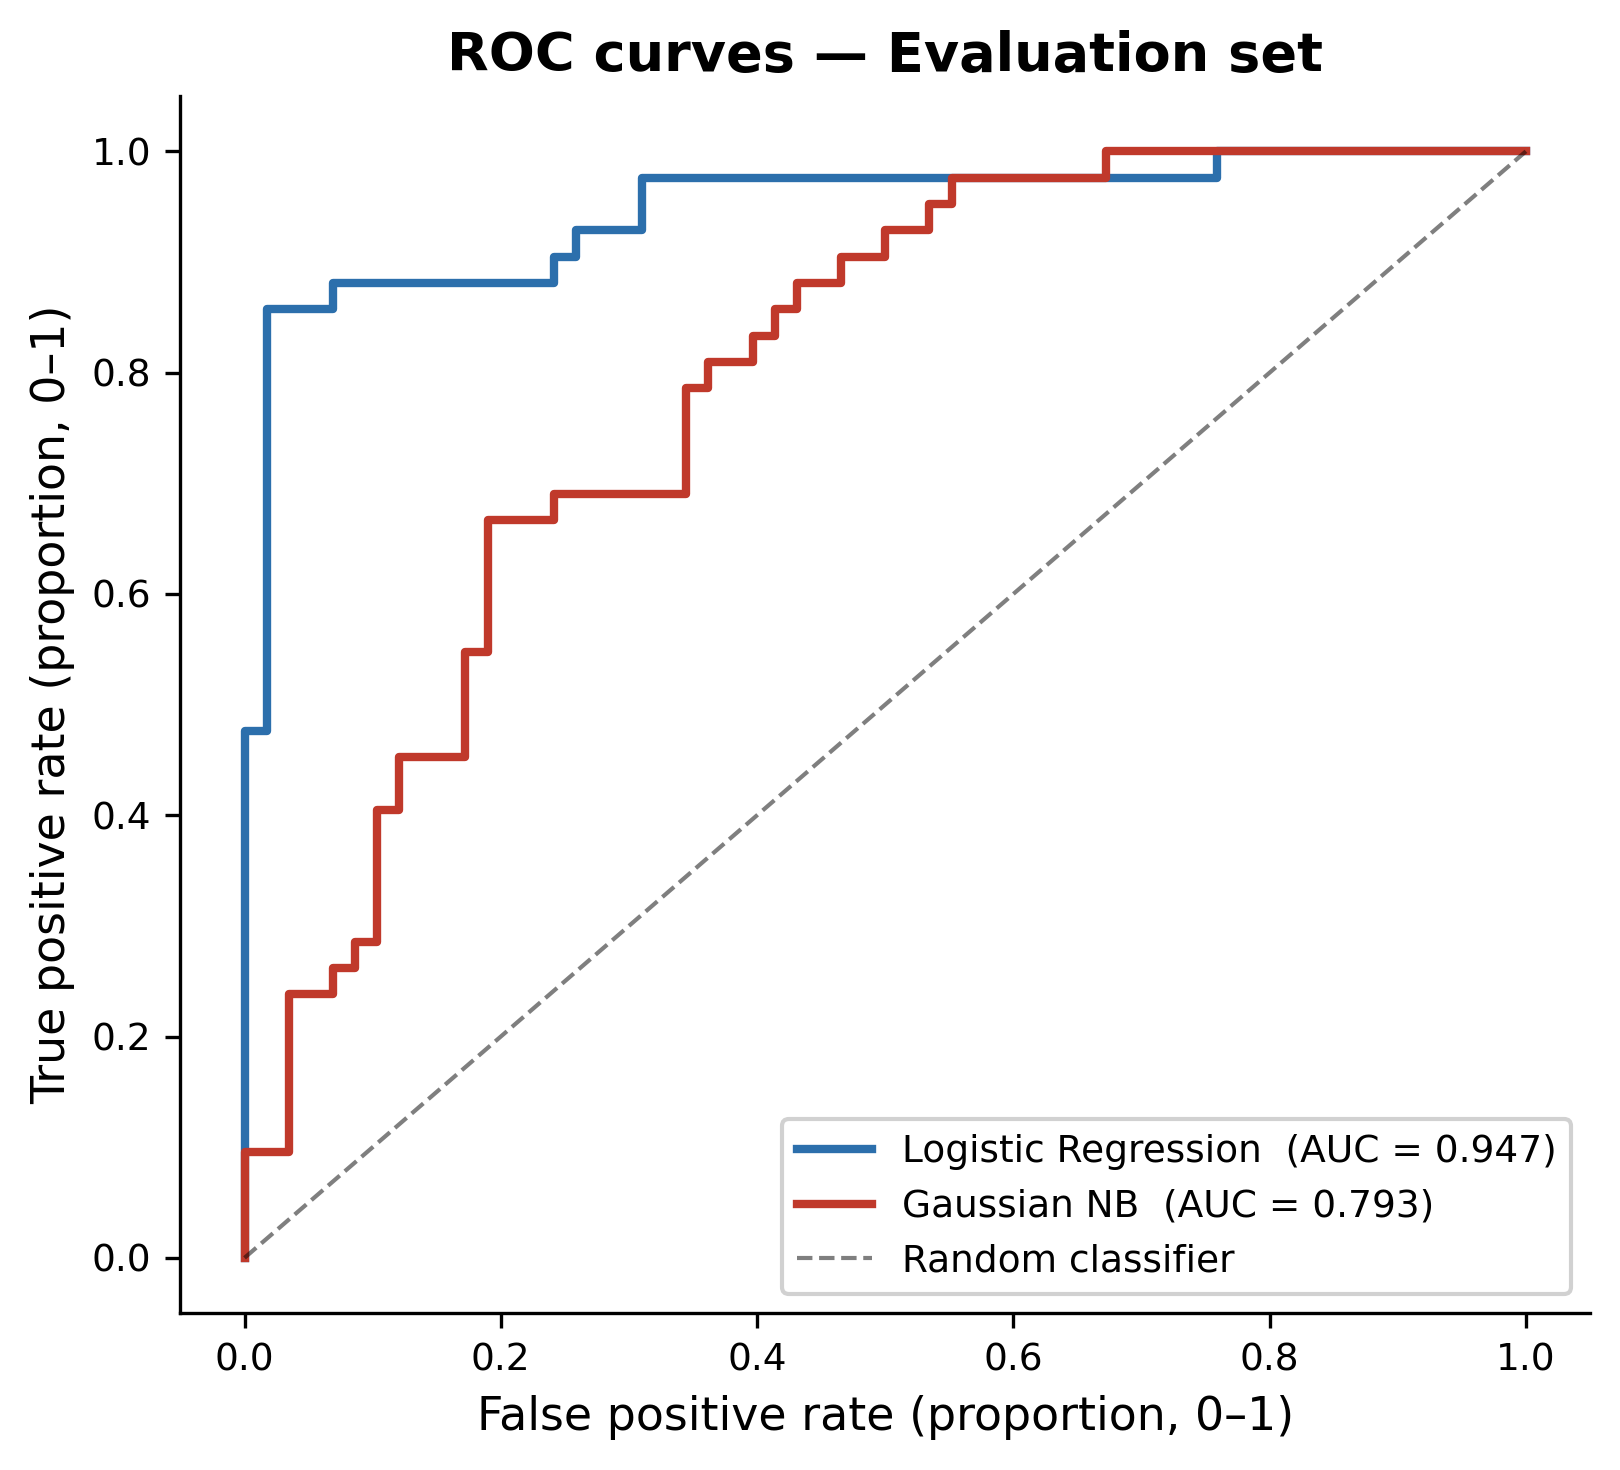

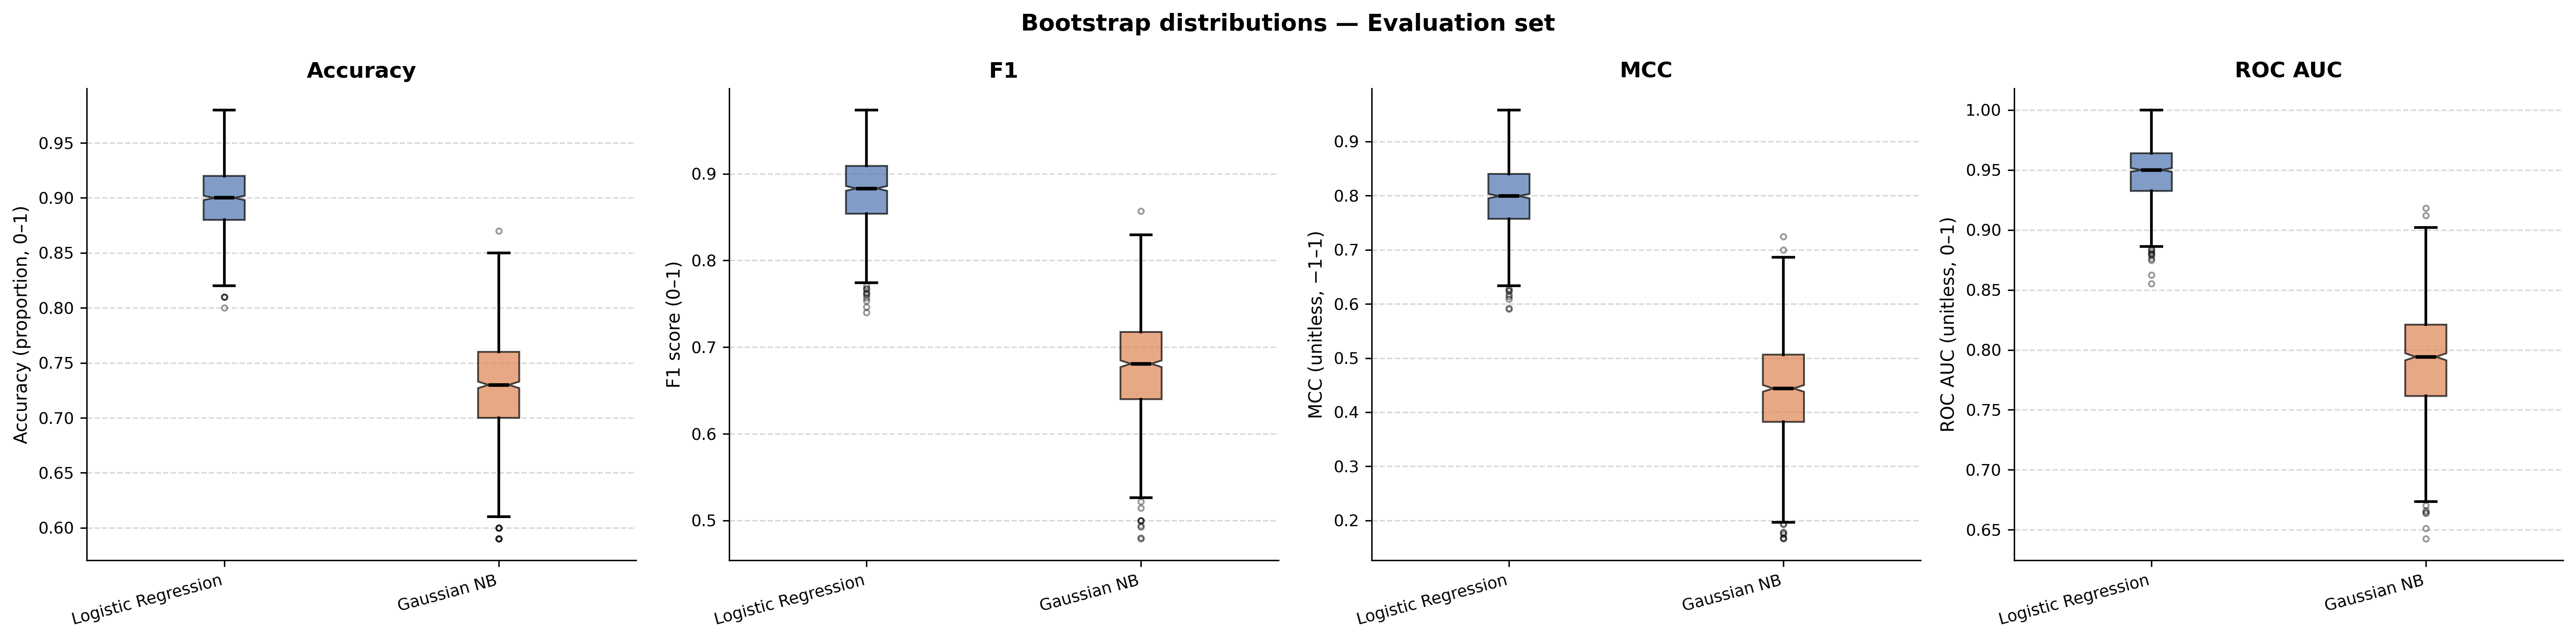

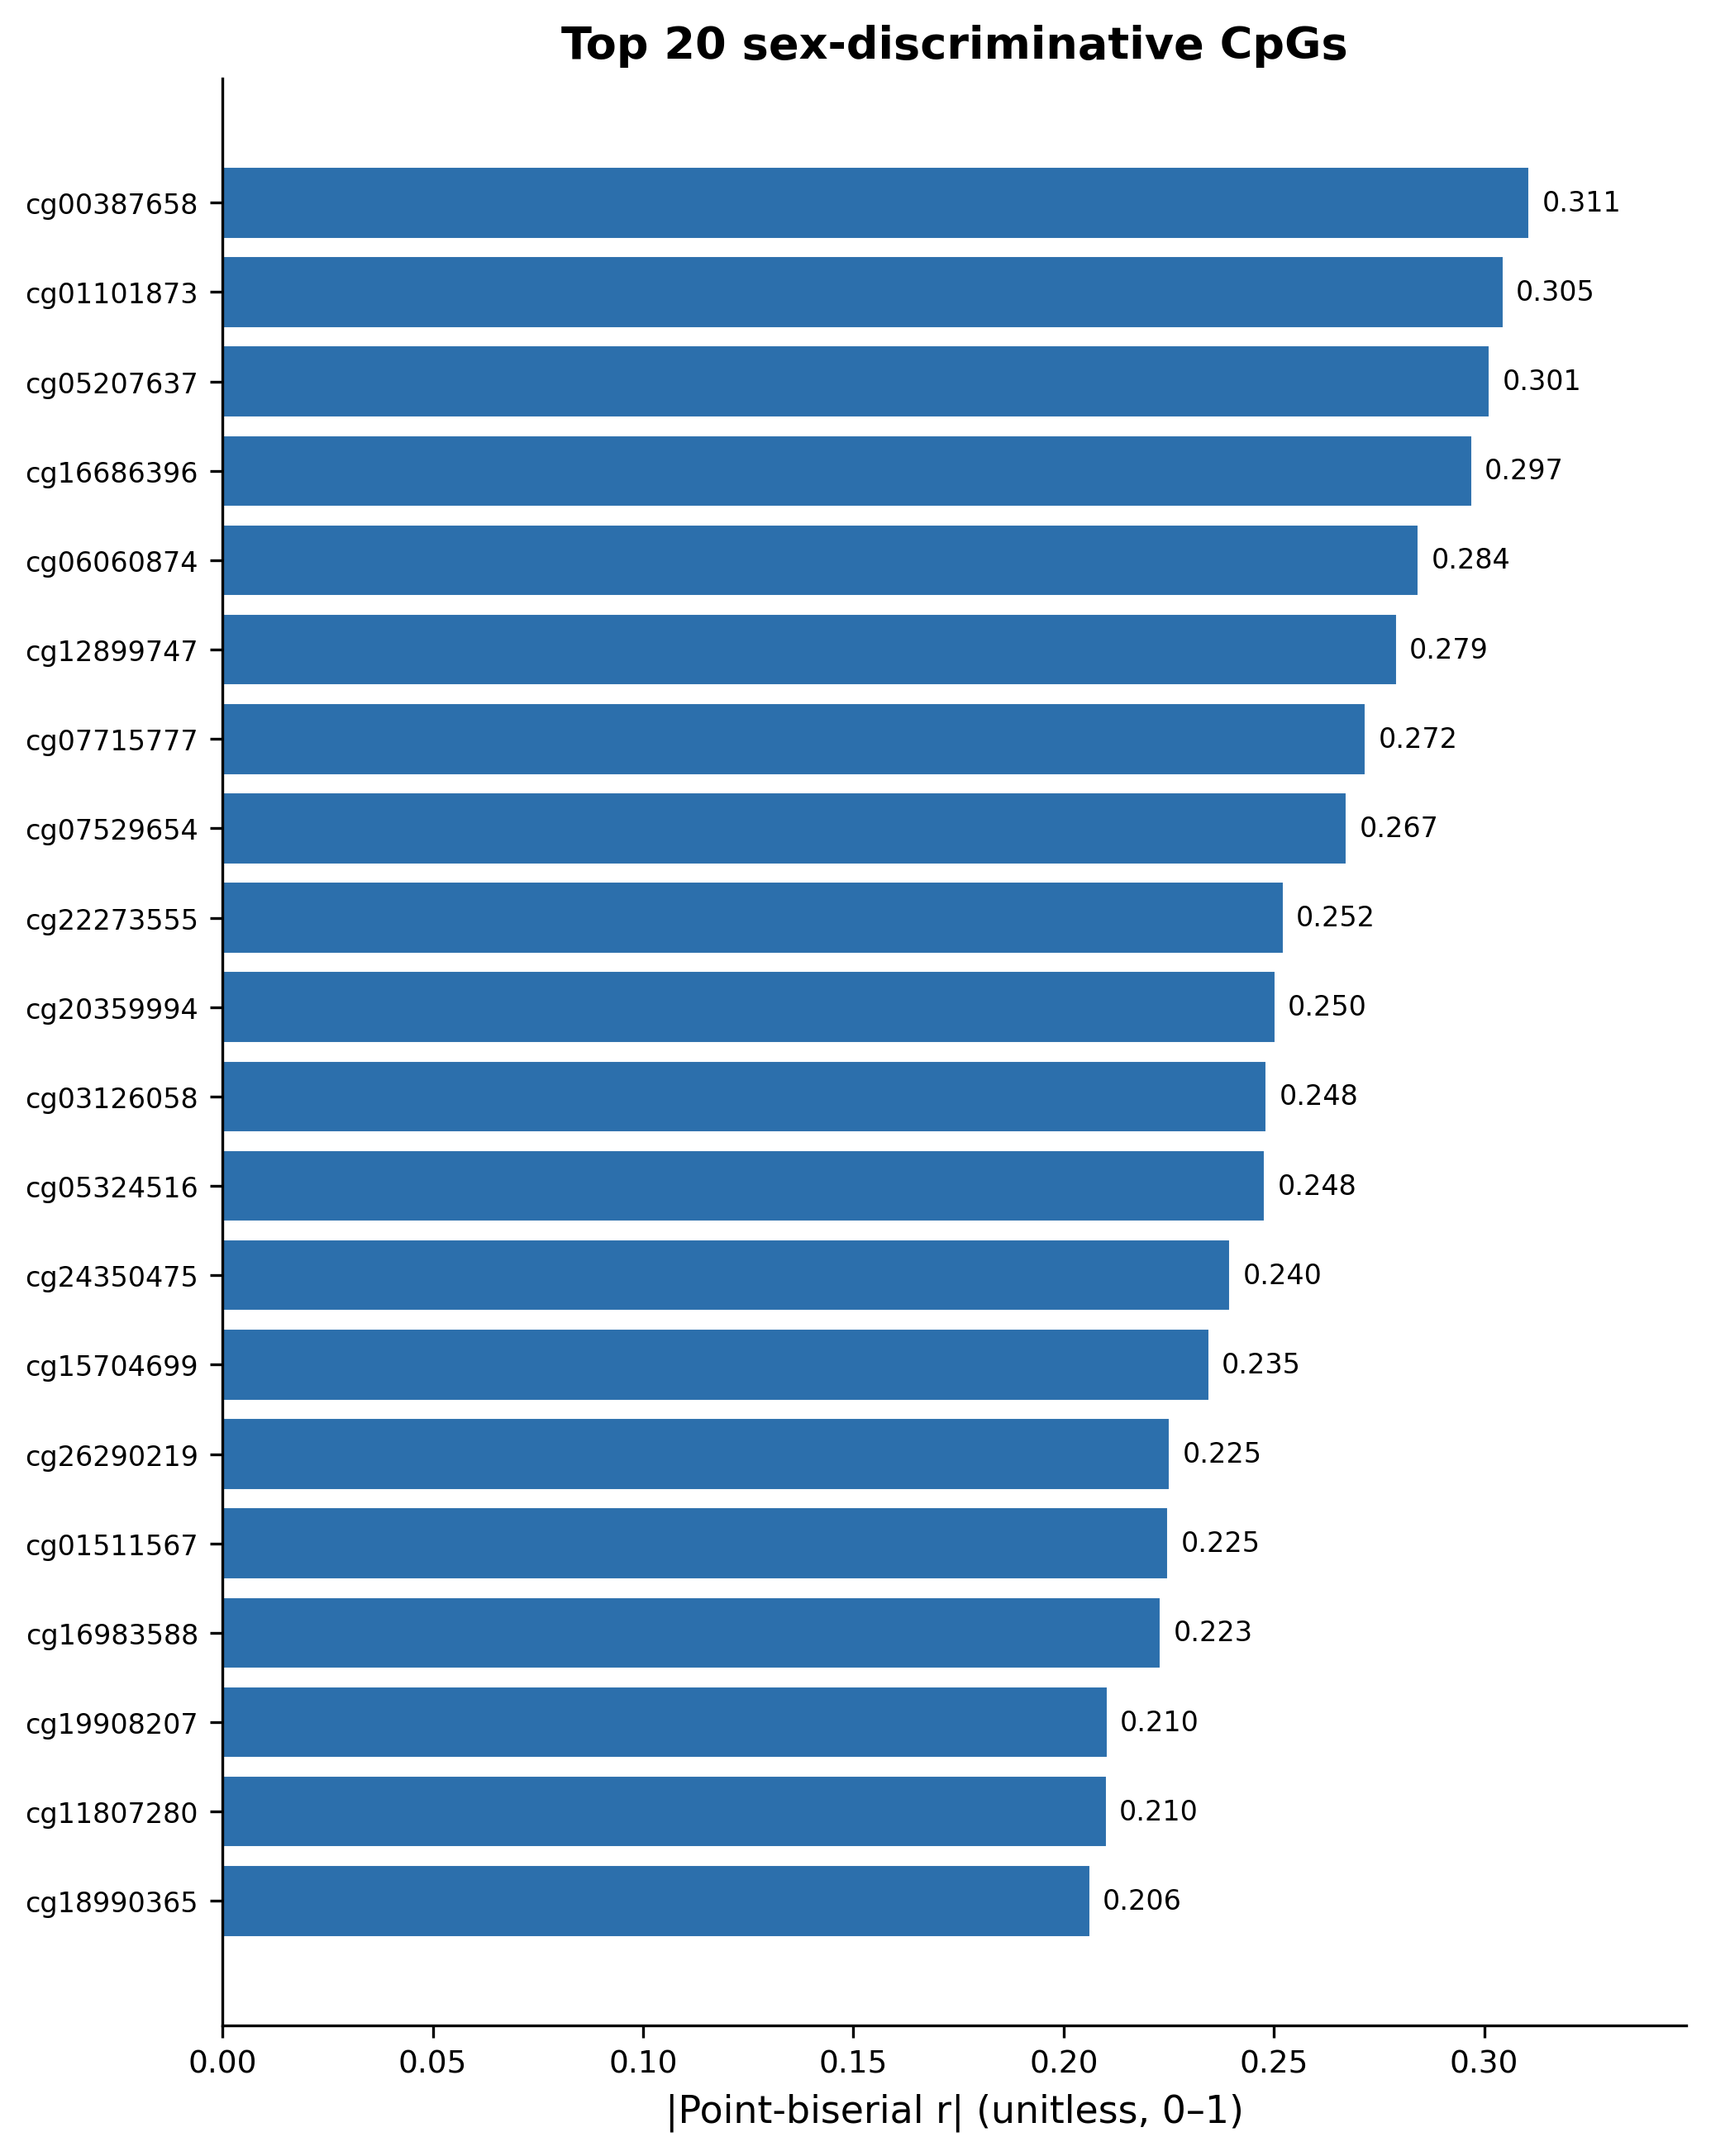

In [3]:
#Reload development and evaluation dataframes
dev_df = pd.read_csv("~/dsit/mlcb/data/development_data.csv")
evaluation_df = pd.read_csv("~/dsit/mlcb/data/evaluation_data.csv")

X_development_classification = build_feature_matrices(dev_df)["2. Methylation Only"]
y_development_classification = dev_df["sex"]

X_evaluate_classification = build_feature_matrices(evaluation_df)["2. Methylation Only"]
y_evaluate_classification = evaluation_df["sex"]

models = {
    "Logistic Regression": LogisticRegression(penalty="l2", max_iter=1000),
    "Gaussian NB":         GaussianNB()
}

results, classification_selectedtopk = classification_pipeline(
    models_dict=models,
    X_development=X_development_classification,
    y_development=y_development_classification,
    X_evaluation=X_evaluate_classification,
    y_evaluation=y_evaluate_classification
)


Visualize the overlap between age selected and sex selected CpG sites

selected_topk: 30
classification_selectedtopk: 30
overlap: 0


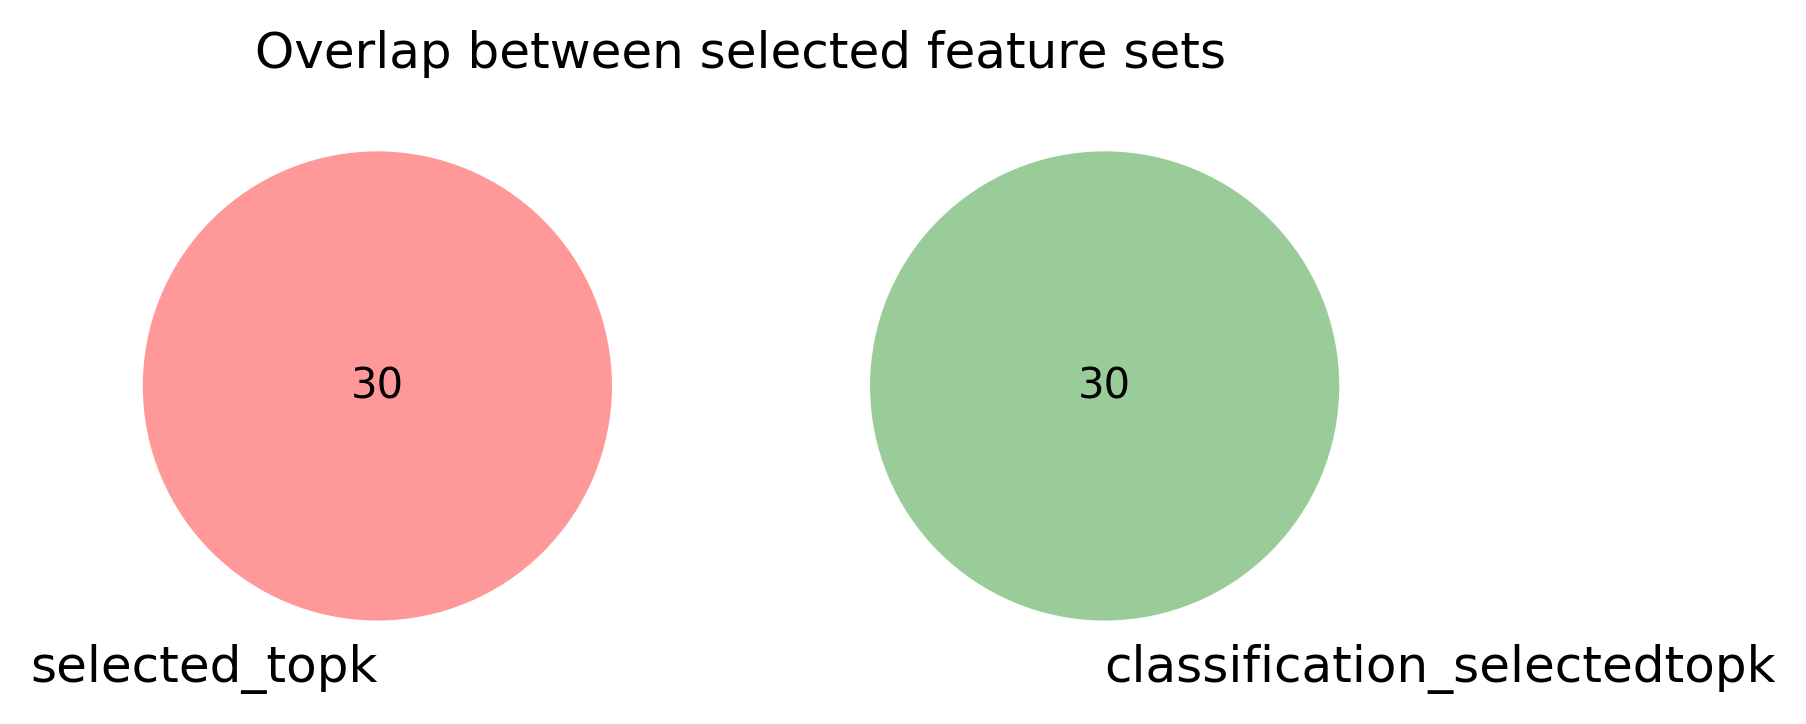

In [ ]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

# Convert to sets
set1 = set(selected_topk)
set2 = set(classification_selectedtopk)

# Basic overlap stats
overlap = set1 & set2
only_set1 = set1 - set2
only_set2 = set2 - set1

print("selected_topk:", len(set1))
print("classification_selectedtopk:", len(set2))
print("overlap:", len(overlap))

# Venn diagram
plt.figure(figsize=(6, 6), dpi=300)
venn2(
    [set1, set2],
    set_labels=("selected_topk", "classification_selectedtopk")
)
plt.title("Overlap between selected feature sets")
plt.tight_layout()
plt.show()